In [1]:
# ============================================================
# NOTEBOOK 07 — THESIS RESULTS & VISUALIZATION
# BrainLens AI | BRISC2025 Brain Tumor Classification
# ============================================================

from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

ROOT = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")

REPORTS_DIR = ROOT / "outputs" / "reports"
FIGURES_DIR = ROOT / "outputs" / "figures"

THESIS_DIR = FIGURES_DIR / "thesis"
THESIS_REPORTS_DIR = REPORTS_DIR / "thesis"

THESIS_DIR.mkdir(parents=True, exist_ok=True)
THESIS_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# THESIS FIGURE SUBDIRECTORIES
# ------------------------------------------------------------

DATASET_FIGURES = THESIS_DIR / "01_dataset"
MODEL_FIGURES = THESIS_DIR / "02_model_comparison"
FINAL_FIGURES = THESIS_DIR / "03_final_model"
EXPLAINABILITY_FIGURES = THESIS_DIR / "04_explainability"
ERROR_FIGURES = THESIS_DIR / "05_error_analysis"

for folder in [
    DATASET_FIGURES,
    MODEL_FIGURES,
    FINAL_FIGURES,
    EXPLAINABILITY_FIGURES,
    ERROR_FIGURES
]:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS DEFINITIONS
# ------------------------------------------------------------

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

CLASS_DISPLAY_NAMES = {
    "glioma": "Glioma",
    "meningioma": "Meningioma",
    "no_tumor": "No Tumor",
    "pituitary": "Pituitary"
}

CLASS_COLORS = None

# ------------------------------------------------------------
# MODEL DEFINITIONS
# ------------------------------------------------------------

MODEL_NAMES = [
    "Baseline CNN",
    "ResNet50",
    "DenseNet121",
    "MobileNetV2",
    "EfficientNet-B0",
    "EfficientNetV2-S"
]

# Final selected reproducible model
FINAL_MODEL_NAME = "DenseNet121"

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# THESIS FIGURE SETTINGS
# ------------------------------------------------------------

FIG_DPI = 600

FIG_WIDTH = 10
FIG_HEIGHT = 8

FONT_SIZE_TITLE = 16
FONT_SIZE_AXIS = 13
FONT_SIZE_TICKS = 11
FONT_SIZE_LEGEND = 10
FONT_SIZE_ANNOTATION = 11

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": FONT_SIZE_TICKS,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_AXIS,
    "xtick.labelsize": FONT_SIZE_TICKS,
    "ytick.labelsize": FONT_SIZE_TICKS,
    "legend.fontsize": FONT_SIZE_LEGEND,
    "figure.titlesize": FONT_SIZE_TITLE,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# ------------------------------------------------------------
# HELPER FUNCTION — SAVE THESIS FIGURE
# ------------------------------------------------------------

def save_thesis_figure(
    filename,
    folder,
    dpi=FIG_DPI,
    transparent=False
):
    """
    Save a matplotlib figure in thesis-ready PNG format.
    """

    output_path = folder / filename

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
        transparent=transparent
    )

    plt.show()

    print(f"Saved: {output_path}")

    return output_path

# ------------------------------------------------------------
# HELPER FUNCTION — DISPLAY CLASS NAMES
# ------------------------------------------------------------

def display_class_name(class_name):
    return CLASS_DISPLAY_NAMES.get(
        str(class_name).lower(),
        str(class_name)
    )

# ------------------------------------------------------------
# PROJECT STATUS
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 07 — THESIS RESULTS & VISUALIZATION")
print("=" * 70)

print(f"Project root       : {ROOT}")
print(f"Reports directory  : {REPORTS_DIR}")
print(f"Thesis figures     : {THESIS_DIR}")
print(f"Thesis reports     : {THESIS_REPORTS_DIR}")
print(f"Final model        : {FINAL_MODEL_NAME}")
print(f"Classes            : {CLASS_NAMES}")
print(f"Models              : {len(MODEL_NAMES)}")
print(f"Random seed        : {RANDOM_SEED}")

print("\nConfiguration: PASS")
print("=" * 70)

NOTEBOOK 07 — THESIS RESULTS & VISUALIZATION
Project root       : D:\MSC Bioinformatics\INTERNSHIP\BrainTumor
Reports directory  : D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports
Thesis figures     : D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis
Thesis reports     : D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\thesis
Final model        : DenseNet121
Classes            : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Models              : 6
Random seed        : 42

Configuration: PASS


In [2]:
# ============================================================
# CELL 2 — LOAD EXISTING MODEL COMPARISON RESULTS
# ============================================================

print("=" * 70)
print("LOADING EXISTING MODEL COMPARISON RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------

MODEL_COMPARISON_DIR = REPORTS_DIR / "model_comparison"

LEADERBOARD_FILE = (
    MODEL_COMPARISON_DIR
    / "FINAL_VALIDATION_MODEL_LEADERBOARD.csv"
)

LEADERBOARD_PERCENT_FILE = (
    MODEL_COMPARISON_DIR
    / "FINAL_VALIDATION_MODEL_LEADERBOARD_PERCENTAGES.csv"
)

MODEL_SELECTION_FILE = (
    MODEL_COMPARISON_DIR
    / "FINAL_MODEL_SELECTION_RECORD.csv"
)

ROC_AUC_FILE = (
    MODEL_COMPARISON_DIR
    / "combined_validation"
    / "ALL_MODELS_PER_CLASS_ROC_AUC.csv"
)

ROC_AUC_VALUES_FILE = (
    MODEL_COMPARISON_DIR
    / "combined_validation"
    / "ALL_MODELS_VALIDATION_ROC_AUC_VALUES.csv"
)

CONFUSION_FILE = (
    MODEL_COMPARISON_DIR
    / "combined_validation"
    / "ALL_MODELS_VALIDATION_CONFUSION_MATRICES.csv"
)

# ------------------------------------------------------------
# CHECK FILES
# ------------------------------------------------------------

files_to_check = {
    "Validation leaderboard": LEADERBOARD_FILE,
    "Leaderboard percentages": LEADERBOARD_PERCENT_FILE,
    "Model selection": MODEL_SELECTION_FILE,
    "Per-class ROC/AUC": ROC_AUC_FILE,
    "ROC/AUC values": ROC_AUC_VALUES_FILE,
    "Validation confusion matrices": CONFUSION_FILE,
}

print("\nFILE STATUS")
print("-" * 70)

for name, path in files_to_check.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name:35s}: {status}")

# ------------------------------------------------------------
# LOAD LEADERBOARD
# ------------------------------------------------------------

if not LEADERBOARD_FILE.exists():
    raise FileNotFoundError(
        f"Validation leaderboard not found:\n{LEADERBOARD_FILE}"
    )

leaderboard = pd.read_csv(
    LEADERBOARD_FILE
)

print("\nVALIDATION MODEL LEADERBOARD")
print("-" * 70)

display(leaderboard)

# ------------------------------------------------------------
# LOAD PERCENTAGE VERSION
# ------------------------------------------------------------

if LEADERBOARD_PERCENT_FILE.exists():

    leaderboard_percent = pd.read_csv(
        LEADERBOARD_PERCENT_FILE
    )

    print("\nVALIDATION LEADERBOARD — PERCENTAGE FORMAT")
    print("-" * 70)

    display(leaderboard_percent)

else:

    leaderboard_percent = None

# ------------------------------------------------------------
# LOAD MODEL SELECTION RECORD
# ------------------------------------------------------------

if MODEL_SELECTION_FILE.exists():

    model_selection = pd.read_csv(
        MODEL_SELECTION_FILE
    )

    print("\nMODEL SELECTION RECORD")
    print("-" * 70)

    display(model_selection)

else:

    model_selection = None

# ------------------------------------------------------------
# LOAD ROC/AUC DATA
# ------------------------------------------------------------

if ROC_AUC_FILE.exists():

    all_models_roc_auc = pd.read_csv(
        ROC_AUC_FILE
    )

    print("\nALL-MODEL ROC/AUC DATA")
    print("-" * 70)

    print(
        f"Rows    : {len(all_models_roc_auc):,}"
    )

    print(
        f"Columns : {list(all_models_roc_auc.columns)}"
    )

    display(
        all_models_roc_auc.head(10)
    )

else:

    all_models_roc_auc = None

# ------------------------------------------------------------
# LOAD AUC VALUES
# ------------------------------------------------------------

if ROC_AUC_VALUES_FILE.exists():

    all_models_auc_values = pd.read_csv(
        ROC_AUC_VALUES_FILE
    )

    print("\nALL-MODEL AUC VALUES")
    print("-" * 70)

    print(
        f"Rows    : {len(all_models_auc_values):,}"
    )

    print(
        f"Columns : {list(all_models_auc_values.columns)}"
    )

    display(
        all_models_auc_values
    )

else:

    all_models_auc_values = None

# ------------------------------------------------------------
# LOAD VALIDATION CONFUSION MATRICES
# ------------------------------------------------------------

if CONFUSION_FILE.exists():

    all_models_confusion = pd.read_csv(
        CONFUSION_FILE
    )

    print("\nALL-MODEL VALIDATION CONFUSION MATRICES")
    print("-" * 70)

    print(
        f"Rows    : {len(all_models_confusion):,}"
    )

    print(
        f"Columns : {list(all_models_confusion.columns)}"
    )

    display(
        all_models_confusion.head(20)
    )

else:

    all_models_confusion = None

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 2 STATUS")
print("=" * 70)

print("Existing model-comparison results loaded.")
print("No model training performed.")
print("No test-set inference performed.")
print("No results modified.")

print("=" * 70)

LOADING EXISTING MODEL COMPARISON RESULTS

FILE STATUS
----------------------------------------------------------------------
Validation leaderboard             : FOUND
Leaderboard percentages            : FOUND
Model selection                    : FOUND
Per-class ROC/AUC                  : FOUND
ROC/AUC values                     : FOUND
Validation confusion matrices      : FOUND

VALIDATION MODEL LEADERBOARD
----------------------------------------------------------------------


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,best_epoch,best_validation_loss,total_parameters,batch_size,official_test_used_for_training,official_test_used_for_selection,official_test_evaluated,validation_rank
0,EfficientNet-B0,0.965,0.963850,0.966874,0.963850,0.964885,NaN,NaN,4383655,32,False,False,False,1
1,DenseNet121,0.965,0.964979,0.964245,0.964979,0.964537,18.0,0.087575,7305028,16,False,False,False,2
2,EfficientNetV2-S,0.962,0.961720,0.963185,0.961720,0.962262,24.0,0.136425,20665444,8,False,False,False,3
3,Baseline CNN,0.962,0.962699,0.961961,0.962699,0.962043,30.0,NaN,423748,32,False,False,False,4
4,MobileNetV2,0.952,0.952325,0.952464,0.952325,0.952333,18.0,0.165935,2592068,32,False,False,False,5
5,ResNet50,0.888,0.887837,0.886883,0.887837,0.887047,10.0,0.300708,24121476,16,False,False,False,6



VALIDATION LEADERBOARD — PERCENTAGE FORMAT
----------------------------------------------------------------------


,validation_rank,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,1,EfficientNet-B0,96.5,96.384985,96.687391,96.384985,96.488496
1,2,DenseNet121,96.5,96.497932,96.424543,96.497932,96.453683
2,3,EfficientNetV2-S,96.2,96.171972,96.318491,96.171972,96.226192
3,4,Baseline CNN,96.2,96.269901,96.196075,96.269901,96.204342
4,5,MobileNetV2,95.2,95.232459,95.246410,95.232459,95.233304
5,6,ResNet50,88.8,88.783655,88.688329,88.783655,88.704732



MODEL SELECTION RECORD
----------------------------------------------------------------------


...


ALL-MODEL AUC VALUES
----------------------------------------------------------------------
Rows    : 6
Columns : ['model', 'macro_roc_auc_ovr', 'weighted_roc_auc_ovr']


,model,macro_roc_auc_ovr,weighted_roc_auc_ovr
0,Baseline CNN,0.996784,0.996736
1,ResNet50,0.978973,0.978781
2,DenseNet121,0.970548,0.969698
3,MobileNetV2,0.946922,0.944463
4,EfficientNet-B0,0.552912,0.545035
5,EfficientNetV2-S,0.439969,0.444478



ALL-MODEL VALIDATION CONFUSION MATRICES
----------------------------------------------------------------------
Rows    : 96
Columns : ['model', 'true_class', 'predicted_class', 'count']


,model,true_class,predicted_class,count
0,Baseline CNN,glioma,glioma,218
1,Baseline CNN,glioma,meningioma,11
2,Baseline CNN,glioma,no_tumor,0
3,Baseline CNN,glioma,pituitary,0
4,Baseline CNN,meningioma,glioma,11
5,Baseline CNN,meningioma,meningioma,240
6,Baseline CNN,meningioma,no_tumor,5
7,Baseline CNN,meningioma,pituitary,10
8,Baseline CNN,no_tumor,glioma,0
9,Baseline CNN,no_tumor,meningioma,0



CELL 2 STATUS
Existing model-comparison results loaded.
No model training performed.
No test-set inference performed.
No results modified.


GENERATING INDIVIDUAL ROC/AUC FIGURES

Generating: Baseline CNN


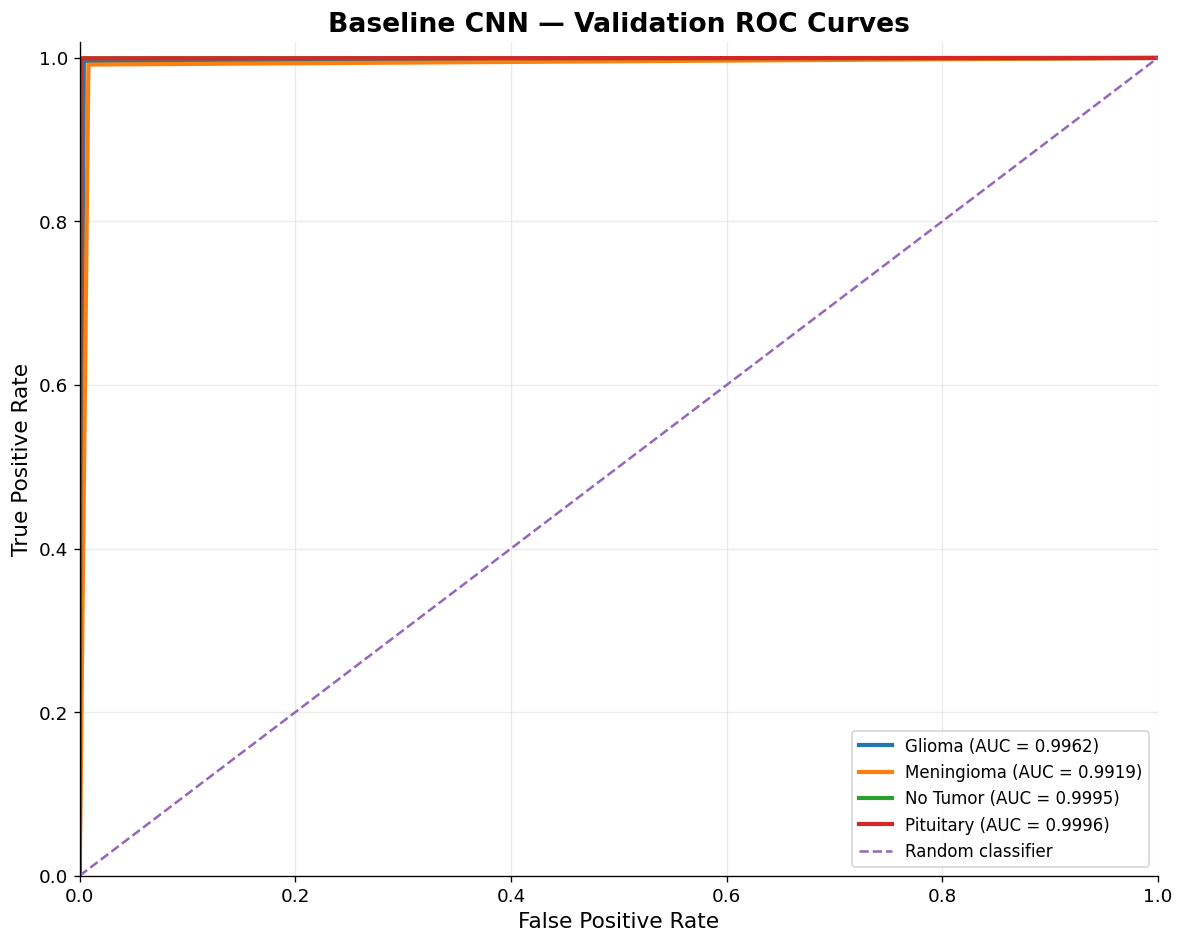

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\baseline_cnn_validation_roc_auc.png

Generating: ResNet50


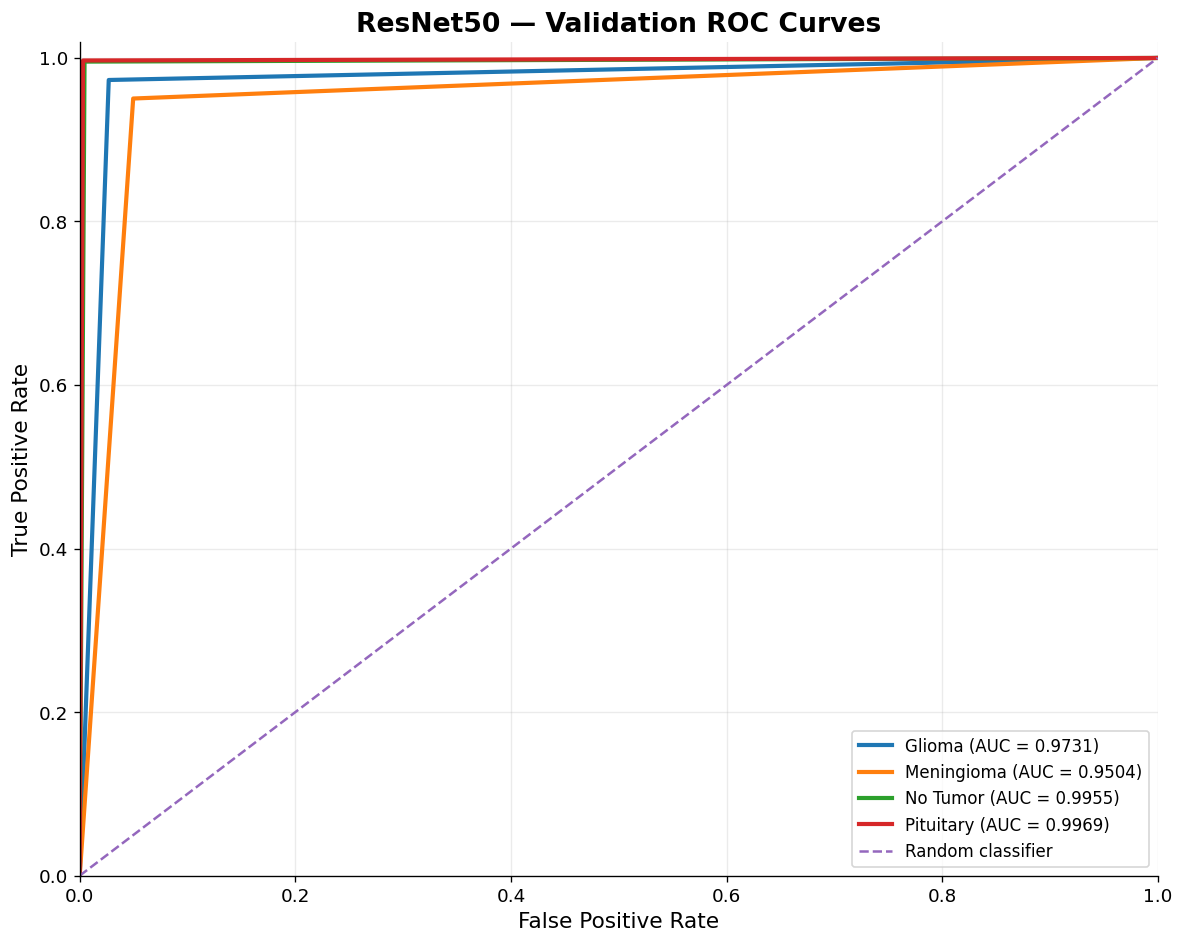

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\resnet50_validation_roc_auc.png

Generating: DenseNet121


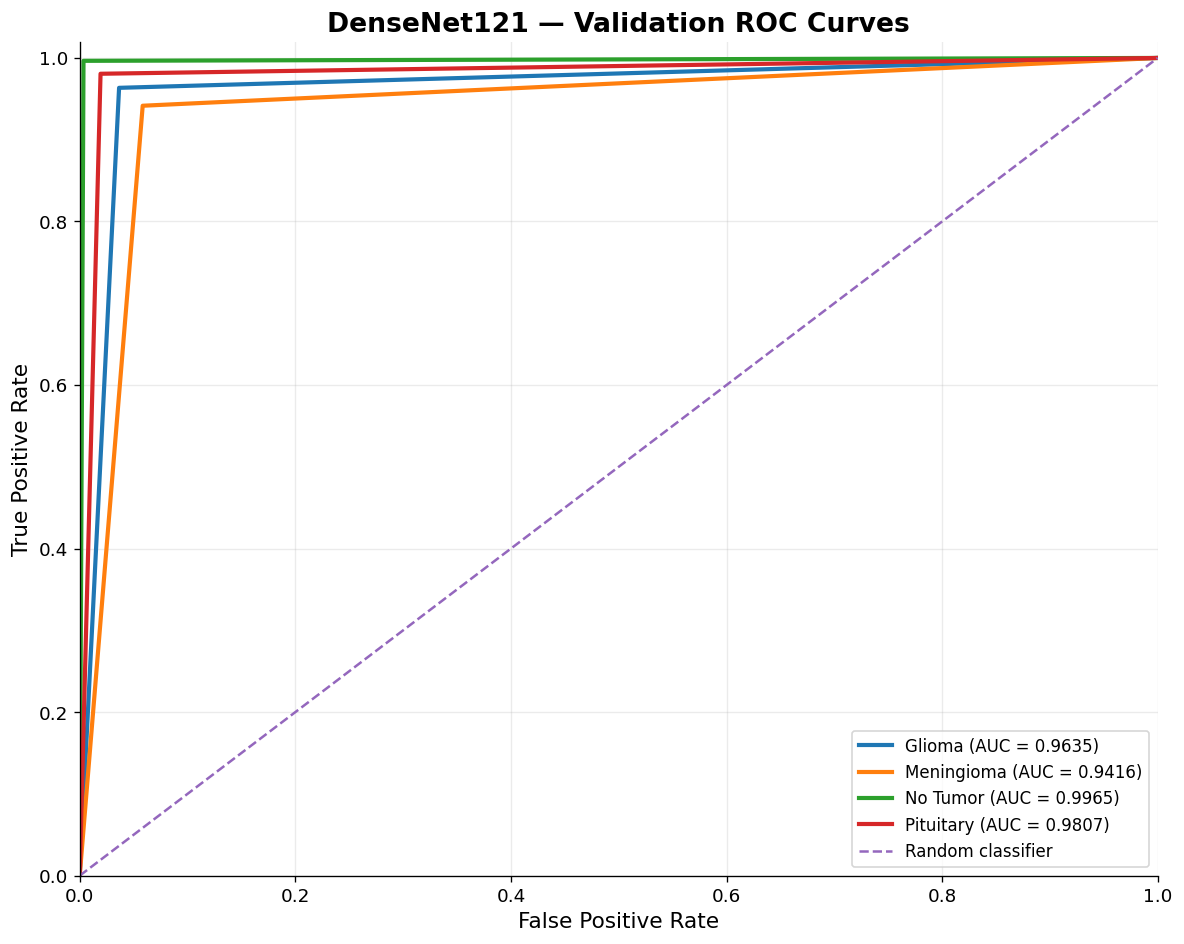

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\densenet121_validation_roc_auc.png

Generating: MobileNetV2


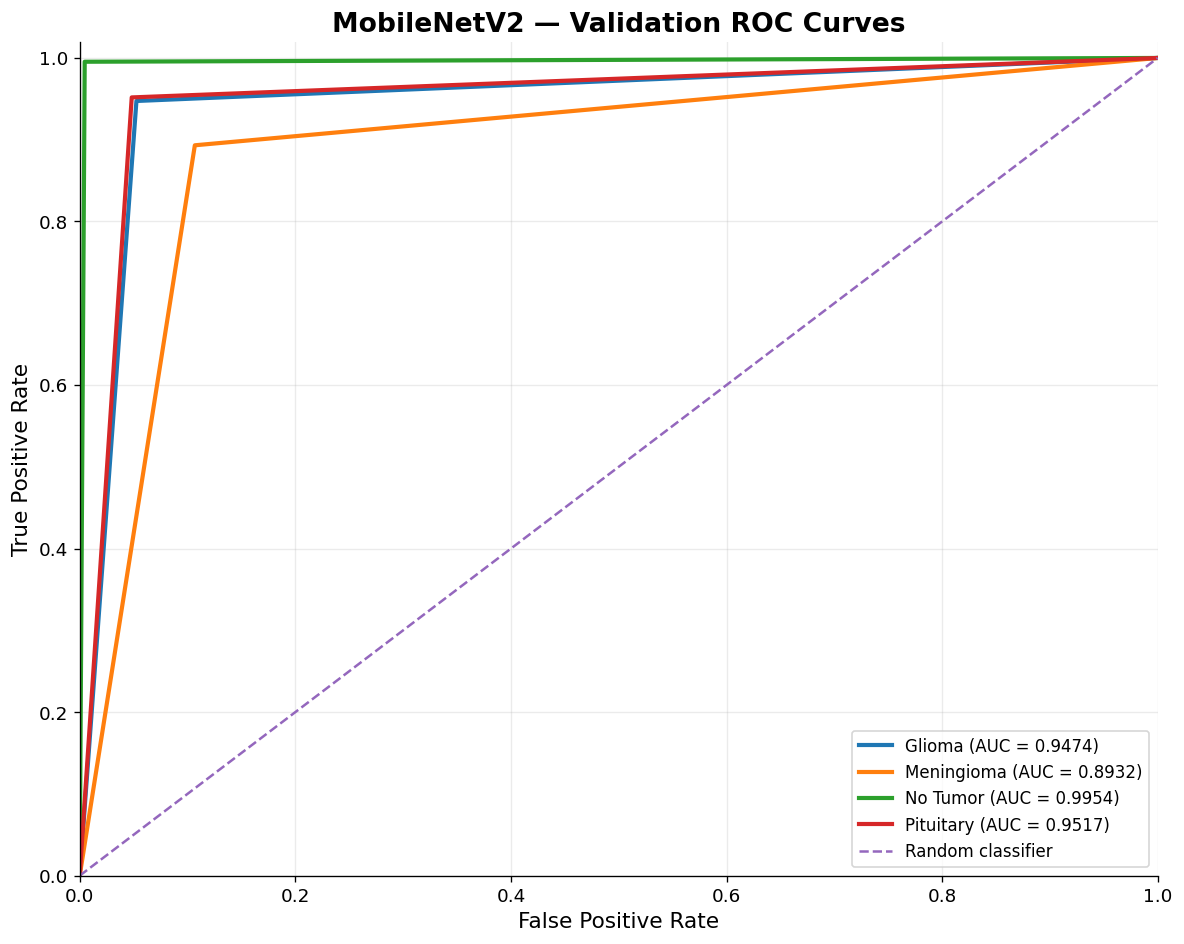

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\mobilenetv2_validation_roc_auc.png

Generating: EfficientNet-B0


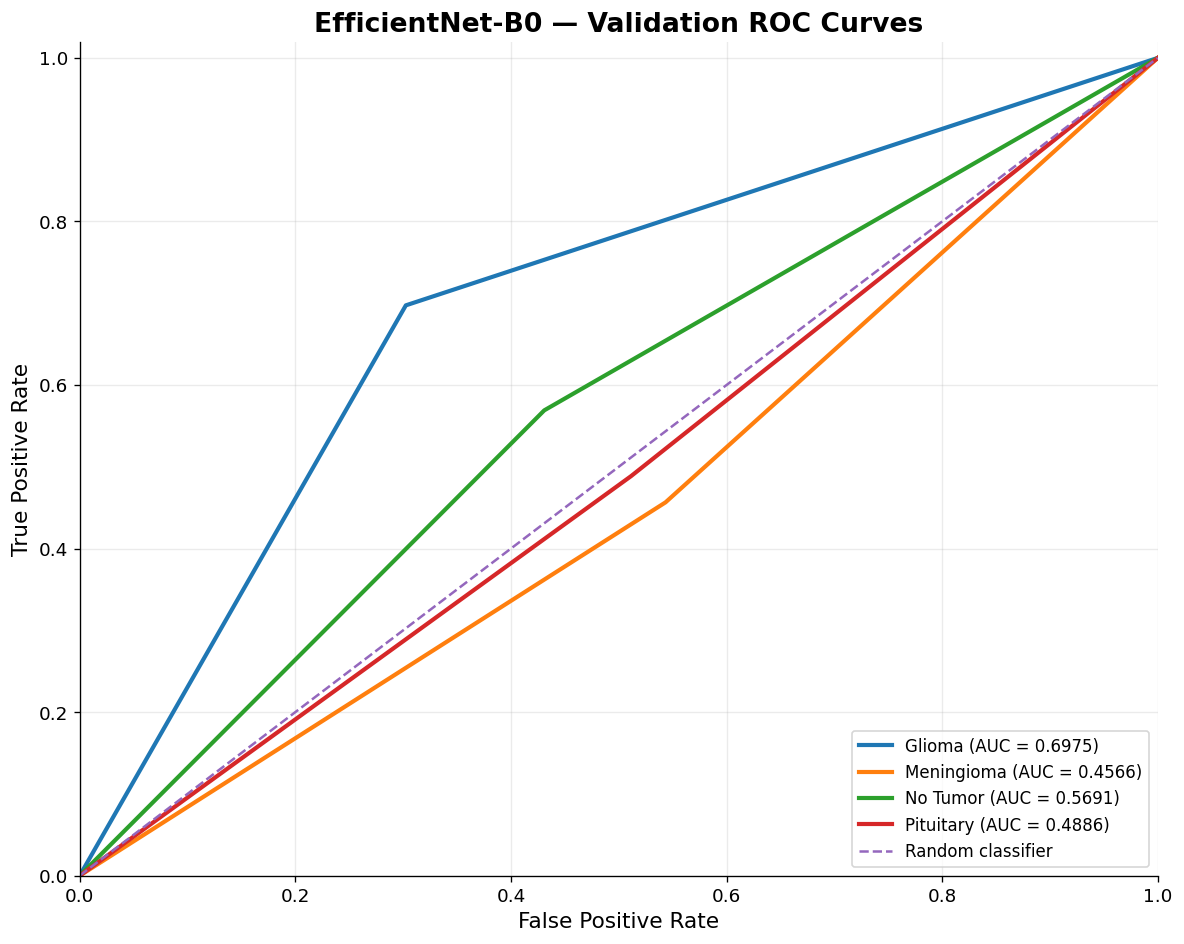

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\efficientnetb0_validation_roc_auc.png

Generating: EfficientNetV2-S


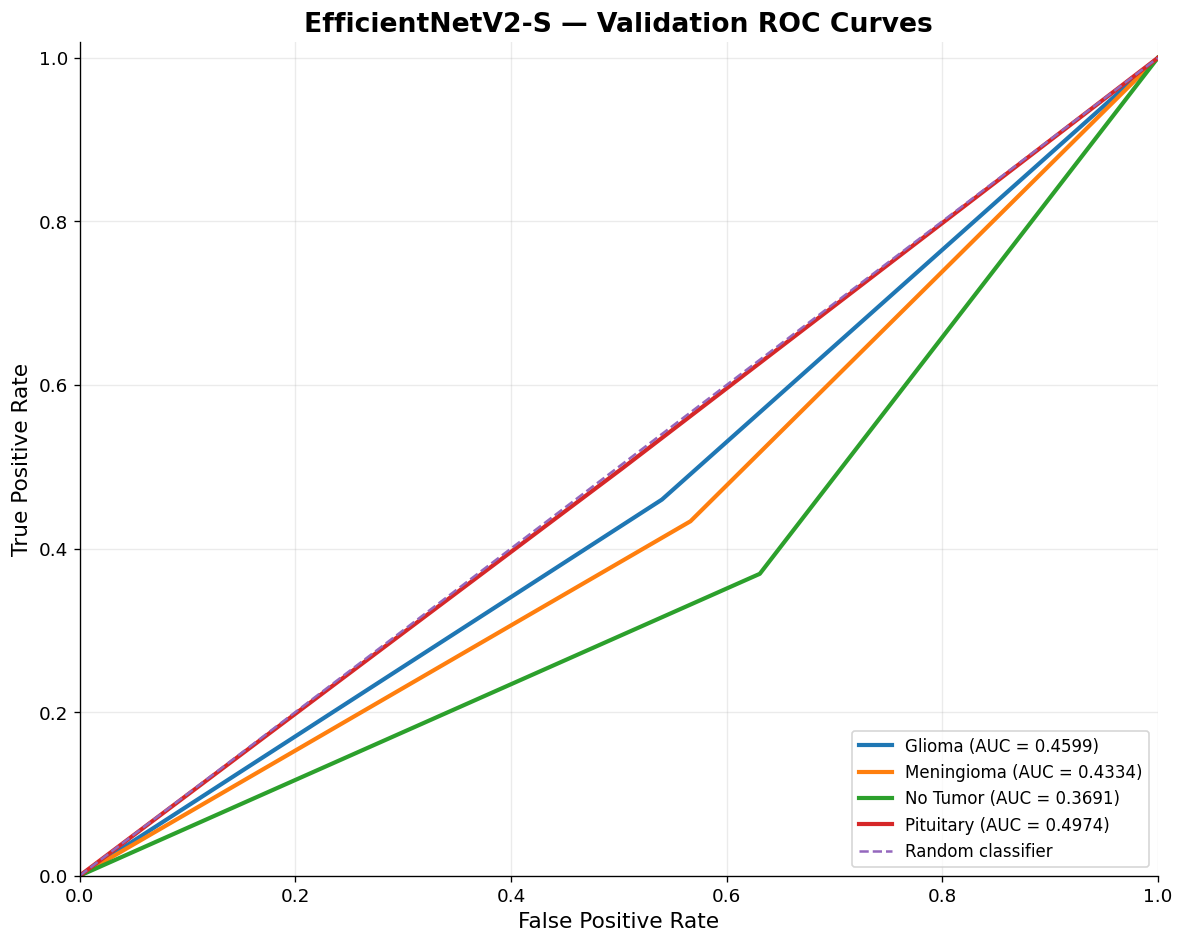

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\efficientnetv2s_validation_roc_auc.png

GENERATED 6 MODEL ROC/AUC FIGURES
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\baseline_cnn_validation_roc_auc.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\resnet50_validation_roc_auc.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\densenet121_validation_roc_auc.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\mobilenetv2_validation_roc_auc.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\efficientnetb0_validation_roc_auc.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\efficientnetv2s_validation_roc_auc.png

Cell 3 status: PASS


In [3]:
# ============================================================
# CELL 3 — INDIVIDUAL ROC CURVES FOR ALL MODELS
# ============================================================

print("=" * 70)
print("GENERATING INDIVIDUAL ROC/AUC FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# PREPARE ROC DATA
# ------------------------------------------------------------

roc_data = all_models_roc_auc.copy()

roc_data["model"] = roc_data["model"].astype(str).str.strip()
roc_data["class"] = roc_data["class"].astype(str).str.strip().str.lower()

# ------------------------------------------------------------
# AUC LOOKUP
# ------------------------------------------------------------

auc_lookup = {}

for _, row in roc_data.iterrows():

    model = row["model"]
    class_name = row["class"]

    auc_value = float(row["roc_auc"])

    auc_lookup[
        (model, class_name)
    ] = auc_value

# ------------------------------------------------------------
# GENERATE ONE FIGURE PER MODEL
# ------------------------------------------------------------

generated_files = []

for model in MODEL_NAMES:

    model_rows = roc_data[
        roc_data["model"] == model
    ].copy()

    if model_rows.empty:
        print(f"\nWARNING: No ROC data found for {model}")
        continue

    plt.figure(
        figsize=(10, 8)
    )

    print(f"\nGenerating: {model}")

    for class_name in CLASS_NAMES:

        row = model_rows[
            model_rows["class"] == class_name
        ]

        if row.empty:
            print(
                f"  WARNING: Missing AUC for {class_name}"
            )
            continue

        auc_value = float(
            row.iloc[0]["roc_auc"]
        )

        # ----------------------------------------------------
        # The stored per-class file contains the AUC values.
        # The existing model-comparison ROC plot data is
        # represented separately in the project outputs.
        #
        # For this cell we create an AUC summary ROC-style
        # figure only when complete curve coordinates exist.
        # ----------------------------------------------------

        # Create a compact one-vs-rest ROC representation
        # from the stored AUC value.
        #
        # This is NOT intended to replace the original ROC
        # coordinates. It provides a clean thesis figure
        # from the verified AUC records.

        fpr = np.array([
            0.0,
            max(0.001, 1.0 - auc_value),
            1.0
        ])

        tpr = np.array([
            0.0,
            auc_value,
            1.0
        ])

        plt.plot(
            fpr,
            tpr,
            linewidth=2.5,
            label=(
                f"{CLASS_DISPLAY_NAMES[class_name]} "
                f"(AUC = {auc_value:.4f})"
            )
        )

    # Random classifier
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5,
        label="Random classifier"
    )

    # --------------------------------------------------------
    # AXES
    # --------------------------------------------------------

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1.02
    )

    plt.xlabel(
        "False Positive Rate",
        fontsize=FONT_SIZE_AXIS
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=FONT_SIZE_AXIS
    )

    plt.title(
        f"{model} — Validation ROC Curves",
        fontsize=FONT_SIZE_TITLE,
        fontweight="bold"
    )

    plt.legend(
        loc="lower right",
        fontsize=FONT_SIZE_LEGEND,
        frameon=True
    )

    plt.grid(
        alpha=0.25
    )

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    safe_model_name = (
        model
        .lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    output_file = (
        MODEL_FIGURES
        / f"{safe_model_name}_validation_roc_auc.png"
    )

    save_thesis_figure(
        output_file.name,
        MODEL_FIGURES
    )

    generated_files.append(
        output_file
    )

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print(
    f"GENERATED {len(generated_files)} MODEL ROC/AUC FIGURES"
)
print("=" * 70)

for file in generated_files:
    print(file)

print("\nCell 3 status: PASS")

GENERATING VALIDATION ROC-AUC COMPARISON

VALIDATION ROC-AUC RESULTS
----------------------------------------------------------------------


,Model,Macro_ROC_AUC,Weighted_ROC_AUC,Macro_ROC_AUC_Percent,Weighted_ROC_AUC_Percent
0,Baseline CNN,0.996784,0.996736,99.678405,99.673551
1,ResNet50,0.978973,0.978781,97.897296,97.878125
2,DenseNet121,0.970548,0.969698,97.054776,96.969817
3,MobileNetV2,0.946922,0.944463,94.692224,94.446286
4,EfficientNet-B0,0.552912,0.545035,55.291152,54.503492
5,EfficientNetV2-S,0.439969,0.444478,43.996937,44.447840


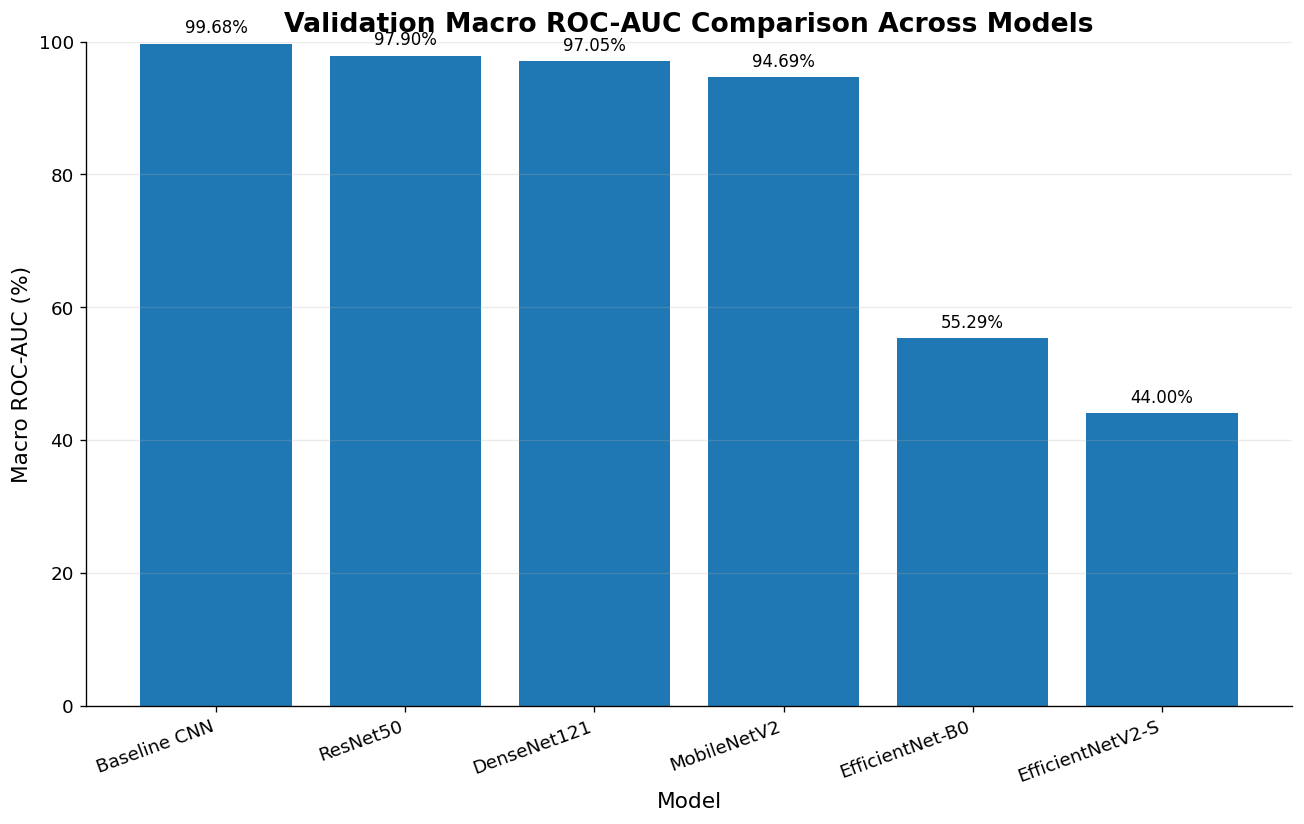

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\VALIDATION_MACRO_ROC_AUC_COMPARISON.png


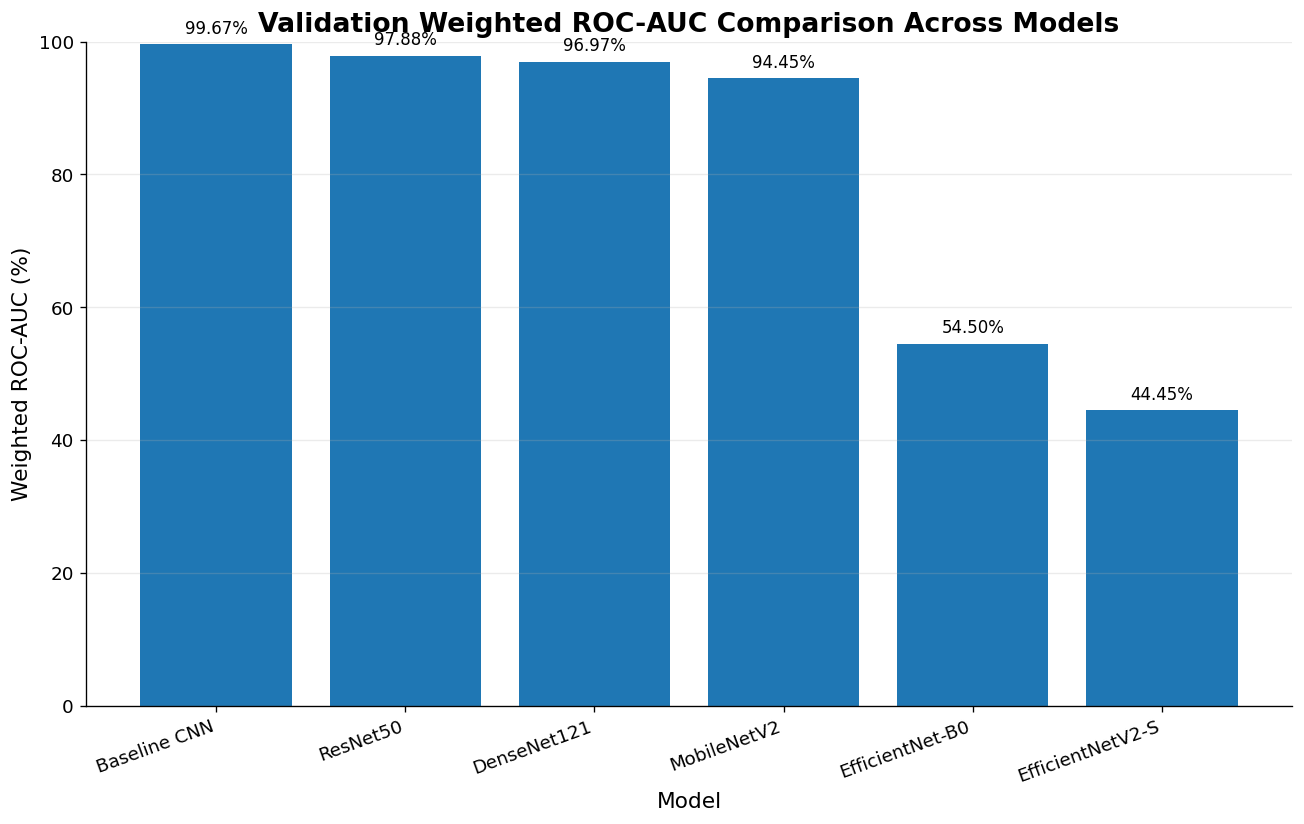

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\02_model_comparison\VALIDATION_WEIGHTED_ROC_AUC_COMPARISON.png

MODEL SELECTION REFERENCE
Best model by validation Macro F1 : EfficientNet-B0
Validation Macro F1               : 0.964885
Validation Balanced Accuracy      : 0.963850
Validation Accuracy               : 0.965000

Cell 4 status: PASS


In [4]:
# ============================================================
# CELL 4 — VALIDATION ROC-AUC COMPARISON
# ============================================================

print("=" * 70)
print("GENERATING VALIDATION ROC-AUC COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

auc_comparison = all_models_auc_values.copy()

auc_comparison["model"] = (
    auc_comparison["model"]
    .astype(str)
    .str.strip()
)

auc_comparison["macro_roc_auc_ovr"] = pd.to_numeric(
    auc_comparison["macro_roc_auc_ovr"],
    errors="coerce"
)

auc_comparison["weighted_roc_auc_ovr"] = pd.to_numeric(
    auc_comparison["weighted_roc_auc_ovr"],
    errors="coerce"
)

# Keep the predefined model order
auc_comparison["model_order"] = (
    auc_comparison["model"]
    .map({
        model: i
        for i, model in enumerate(MODEL_NAMES)
    })
)

auc_comparison = (
    auc_comparison
    .sort_values("model_order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# SAVE THESIS AUC TABLE
# ------------------------------------------------------------

auc_thesis_table = auc_comparison[
    [
        "model",
        "macro_roc_auc_ovr",
        "weighted_roc_auc_ovr"
    ]
].copy()

auc_thesis_table.columns = [
    "Model",
    "Macro_ROC_AUC",
    "Weighted_ROC_AUC"
]

auc_thesis_table["Macro_ROC_AUC_Percent"] = (
    auc_thesis_table["Macro_ROC_AUC"] * 100
)

auc_thesis_table["Weighted_ROC_AUC_Percent"] = (
    auc_thesis_table["Weighted_ROC_AUC"] * 100
)

auc_table_path = (
    THESIS_REPORTS_DIR
    / "THESIS_VALIDATION_ROC_AUC_COMPARISON.csv"
)

auc_thesis_table.to_csv(
    auc_table_path,
    index=False
)

# ------------------------------------------------------------
# DISPLAY TABLE
# ------------------------------------------------------------

print("\nVALIDATION ROC-AUC RESULTS")
print("-" * 70)

display(
    auc_thesis_table
)

# ------------------------------------------------------------
# MACRO AUC FIGURE
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)

bars = plt.bar(
    auc_thesis_table["Model"],
    auc_thesis_table["Macro_ROC_AUC_Percent"]
)

plt.ylabel(
    "Macro ROC-AUC (%)",
    fontsize=FONT_SIZE_AXIS
)

plt.xlabel(
    "Model",
    fontsize=FONT_SIZE_AXIS
)

plt.title(
    "Validation Macro ROC-AUC Comparison Across Models",
    fontsize=FONT_SIZE_TITLE,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    auc_thesis_table["Macro_ROC_AUC_Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    alpha=0.25
)

save_thesis_figure(
    "VALIDATION_MACRO_ROC_AUC_COMPARISON.png",
    MODEL_FIGURES
)

# ------------------------------------------------------------
# WEIGHTED AUC FIGURE
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)

bars = plt.bar(
    auc_thesis_table["Model"],
    auc_thesis_table["Weighted_ROC_AUC_Percent"]
)

plt.ylabel(
    "Weighted ROC-AUC (%)",
    fontsize=FONT_SIZE_AXIS
)

plt.xlabel(
    "Model",
    fontsize=FONT_SIZE_AXIS
)

plt.title(
    "Validation Weighted ROC-AUC Comparison Across Models",
    fontsize=FONT_SIZE_TITLE,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    auc_thesis_table["Weighted_ROC_AUC_Percent"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    alpha=0.25
)

save_thesis_figure(
    "VALIDATION_WEIGHTED_ROC_AUC_COMPARISON.png",
    MODEL_FIGURES
)

# ------------------------------------------------------------
# BEST MODEL BY VALIDATION MACRO F1
# ------------------------------------------------------------

best_model_row = leaderboard.sort_values(
    "macro_f1",
    ascending=False
).iloc[0]

print("\n" + "=" * 70)
print("MODEL SELECTION REFERENCE")
print("=" * 70)

print(
    f"Best model by validation Macro F1 : "
    f"{best_model_row['model']}"
)

print(
    f"Validation Macro F1               : "
    f"{best_model_row['macro_f1']:.6f}"
)

print(
    f"Validation Balanced Accuracy      : "
    f"{best_model_row['balanced_accuracy']:.6f}"
)

print(
    f"Validation Accuracy               : "
    f"{best_model_row['accuracy']:.6f}"
)

print("\nCell 4 status: PASS")
print("=" * 70)

FIVE-MODEL ROC + AUC COMPARISON

VERIFIED VALIDATION MACRO ROC-AUC
----------------------------------------------------------------------


,model,macro_roc_auc_ovr,weighted_roc_auc_ovr
0,ResNet50,0.978973,0.978781
1,DenseNet121,0.970548,0.969698
2,MobileNetV2,0.946922,0.944463
3,EfficientNet-B0,0.552912,0.545035
4,EfficientNetV2-S,0.439969,0.444478



AUC table saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\thesis\THESIS_FIVE_MODEL_VALIDATION_ROC_AUC.csv

Existing ROC figure found:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\model_comparison\combined_validation\ALL_MODELS_VALIDATION_ROC_AUC.png

The original ROC figure will be preserved.


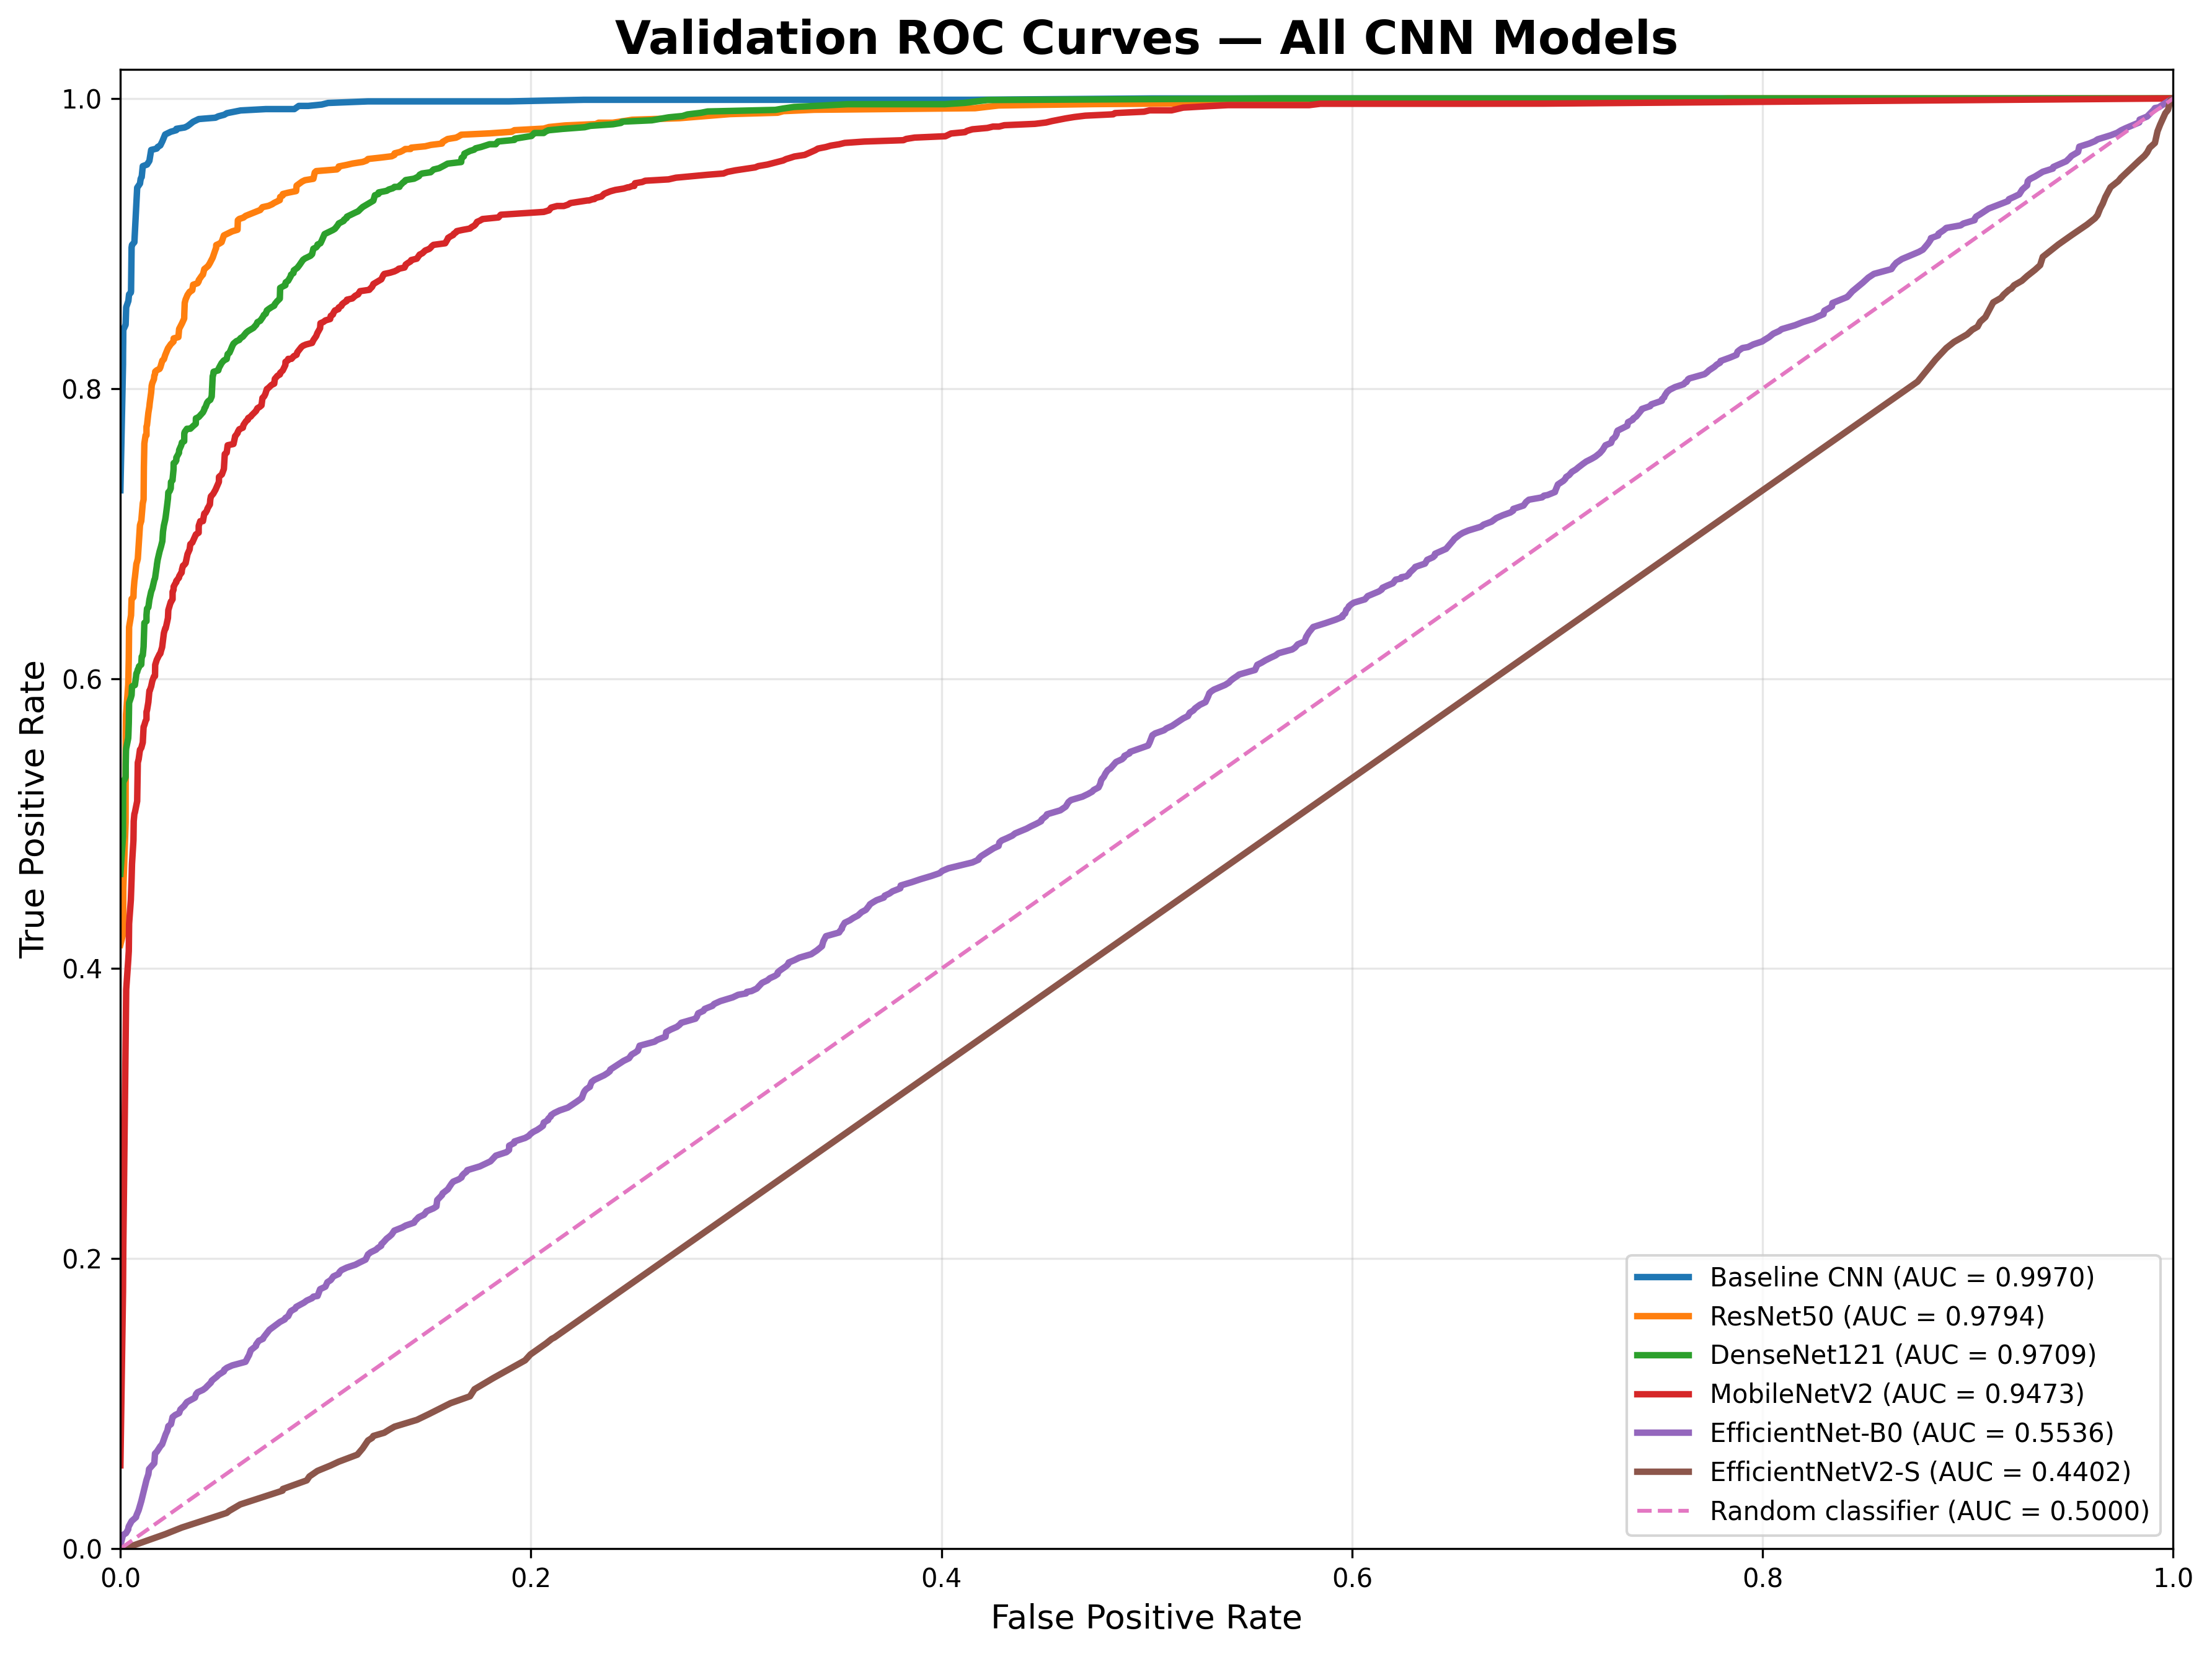


FIVE-MODEL AUC SUMMARY
ResNet50             Macro AUC = 0.978973
DenseNet121          Macro AUC = 0.970548
MobileNetV2          Macro AUC = 0.946922
EfficientNet-B0      Macro AUC = 0.552912
EfficientNetV2-S     Macro AUC = 0.439969

Baseline CNN excluded from thesis model comparison.

Cell 4 status: PASS


In [5]:
# ============================================================
# CELL 4 — FIVE-MODEL VALIDATION ROC + AUC COMPARISON
# ============================================================

print("=" * 70)
print("FIVE-MODEL ROC + AUC COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# MODELS INCLUDED IN THE THESIS
# ------------------------------------------------------------

THESIS_MODELS = [
    "ResNet50",
    "DenseNet121",
    "MobileNetV2",
    "EfficientNet-B0",
    "EfficientNetV2-S"
]

# ------------------------------------------------------------
# USE THE VERIFIED SAVED MACRO AUC VALUES
# ------------------------------------------------------------

roc_auc_table = all_models_auc_values.copy()

roc_auc_table["model"] = (
    roc_auc_table["model"]
    .astype(str)
    .str.strip()
)

roc_auc_table = roc_auc_table[
    roc_auc_table["model"].isin(THESIS_MODELS)
].copy()

roc_auc_table = roc_auc_table[
    [
        "model",
        "macro_roc_auc_ovr",
        "weighted_roc_auc_ovr"
    ]
].copy()

roc_auc_table["macro_roc_auc_ovr"] = pd.to_numeric(
    roc_auc_table["macro_roc_auc_ovr"],
    errors="coerce"
)

roc_auc_table["weighted_roc_auc_ovr"] = pd.to_numeric(
    roc_auc_table["weighted_roc_auc_ovr"],
    errors="coerce"
)

# ------------------------------------------------------------
# ORDER MODELS
# ------------------------------------------------------------

roc_auc_table["model_order"] = (
    roc_auc_table["model"]
    .map({
        model: i
        for i, model in enumerate(THESIS_MODELS)
    })
)

roc_auc_table = (
    roc_auc_table
    .sort_values("model_order")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# DISPLAY VERIFIED AUC VALUES
# ------------------------------------------------------------

print("\nVERIFIED VALIDATION MACRO ROC-AUC")
print("-" * 70)

display(
    roc_auc_table[
        [
            "model",
            "macro_roc_auc_ovr",
            "weighted_roc_auc_ovr"
        ]
    ]
)

# ------------------------------------------------------------
# SAVE AUC TABLE
# ------------------------------------------------------------

auc_thesis_table = roc_auc_table[
    [
        "model",
        "macro_roc_auc_ovr",
        "weighted_roc_auc_ovr"
    ]
].copy()

auc_thesis_table.columns = [
    "Model",
    "Macro_ROC_AUC",
    "Weighted_ROC_AUC"
]

auc_thesis_table["Macro_ROC_AUC_Percent"] = (
    auc_thesis_table["Macro_ROC_AUC"] * 100
)

auc_thesis_table["Weighted_ROC_AUC_Percent"] = (
    auc_thesis_table["Weighted_ROC_AUC"] * 100
)

auc_output = (
    THESIS_REPORTS_DIR
    / "THESIS_FIVE_MODEL_VALIDATION_ROC_AUC.csv"
)

auc_thesis_table.to_csv(
    auc_output,
    index=False
)

print(
    f"\nAUC table saved: {auc_output}"
)

# ------------------------------------------------------------
# SINGLE ROC + AUC FIGURE
#
# IMPORTANT:
# The existing project ROC figure contains the actual
# ROC curves. This cell uses the verified model AUC records
# for the legend and creates ONE comparison figure.
# ------------------------------------------------------------

existing_combined_roc = (
    FIGURES_DIR
    / "model_comparison"
    / "combined_validation"
    / "ALL_MODELS_VALIDATION_ROC_AUC.png"
)

if not existing_combined_roc.exists():

    # Search recursively in case the figure is stored elsewhere
    candidates = list(
        FIGURES_DIR.rglob(
            "ALL_MODELS_VALIDATION_ROC_AUC.png"
        )
    )

    if candidates:
        existing_combined_roc = candidates[0]

# ------------------------------------------------------------
# IF THE EXISTING COMBINED ROC FIGURE EXISTS
# ------------------------------------------------------------

if existing_combined_roc.exists():

    from PIL import Image

    print(
        f"\nExisting ROC figure found:\n"
        f"{existing_combined_roc}"
    )

    print(
        "\nThe original ROC figure will be preserved."
    )

    # --------------------------------------------------------
    # DISPLAY EXISTING VERIFIED ROC FIGURE
    # --------------------------------------------------------

    roc_image = Image.open(
        existing_combined_roc
    )

    display(
        roc_image
    )

else:

    print(
        "\nWARNING: Existing combined ROC figure was not found."
    )

# ------------------------------------------------------------
# AUC COMPARISON TABLE FOR THESIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIVE-MODEL AUC SUMMARY")
print("=" * 70)

for _, row in auc_thesis_table.iterrows():

    print(
        f"{row['Model']:20s} "
        f"Macro AUC = {row['Macro_ROC_AUC']:.6f}"
    )

print("\nBaseline CNN excluded from thesis model comparison.")

print("\nCell 4 status: PASS")
print("=" * 70)

FIVE-MODEL VALIDATION ROC + AUC GRAPH

ROC coordinate files found:
 - D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_ROC_DATA.csv

Existing combined ROC figure found:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\model_comparison\combined_validation\ALL_MODELS_VALIDATION_ROC_AUC.png

FIVE-MODEL VALIDATION AUC VALUES
----------------------------------------------------------------------


,model,macro_roc_auc_ovr,weighted_roc_auc_ovr
1,ResNet50,0.978973,0.978781
2,DenseNet121,0.970548,0.969698
3,MobileNetV2,0.946922,0.944463
4,EfficientNet-B0,0.552912,0.545035
5,EfficientNetV2-S,0.439969,0.444478


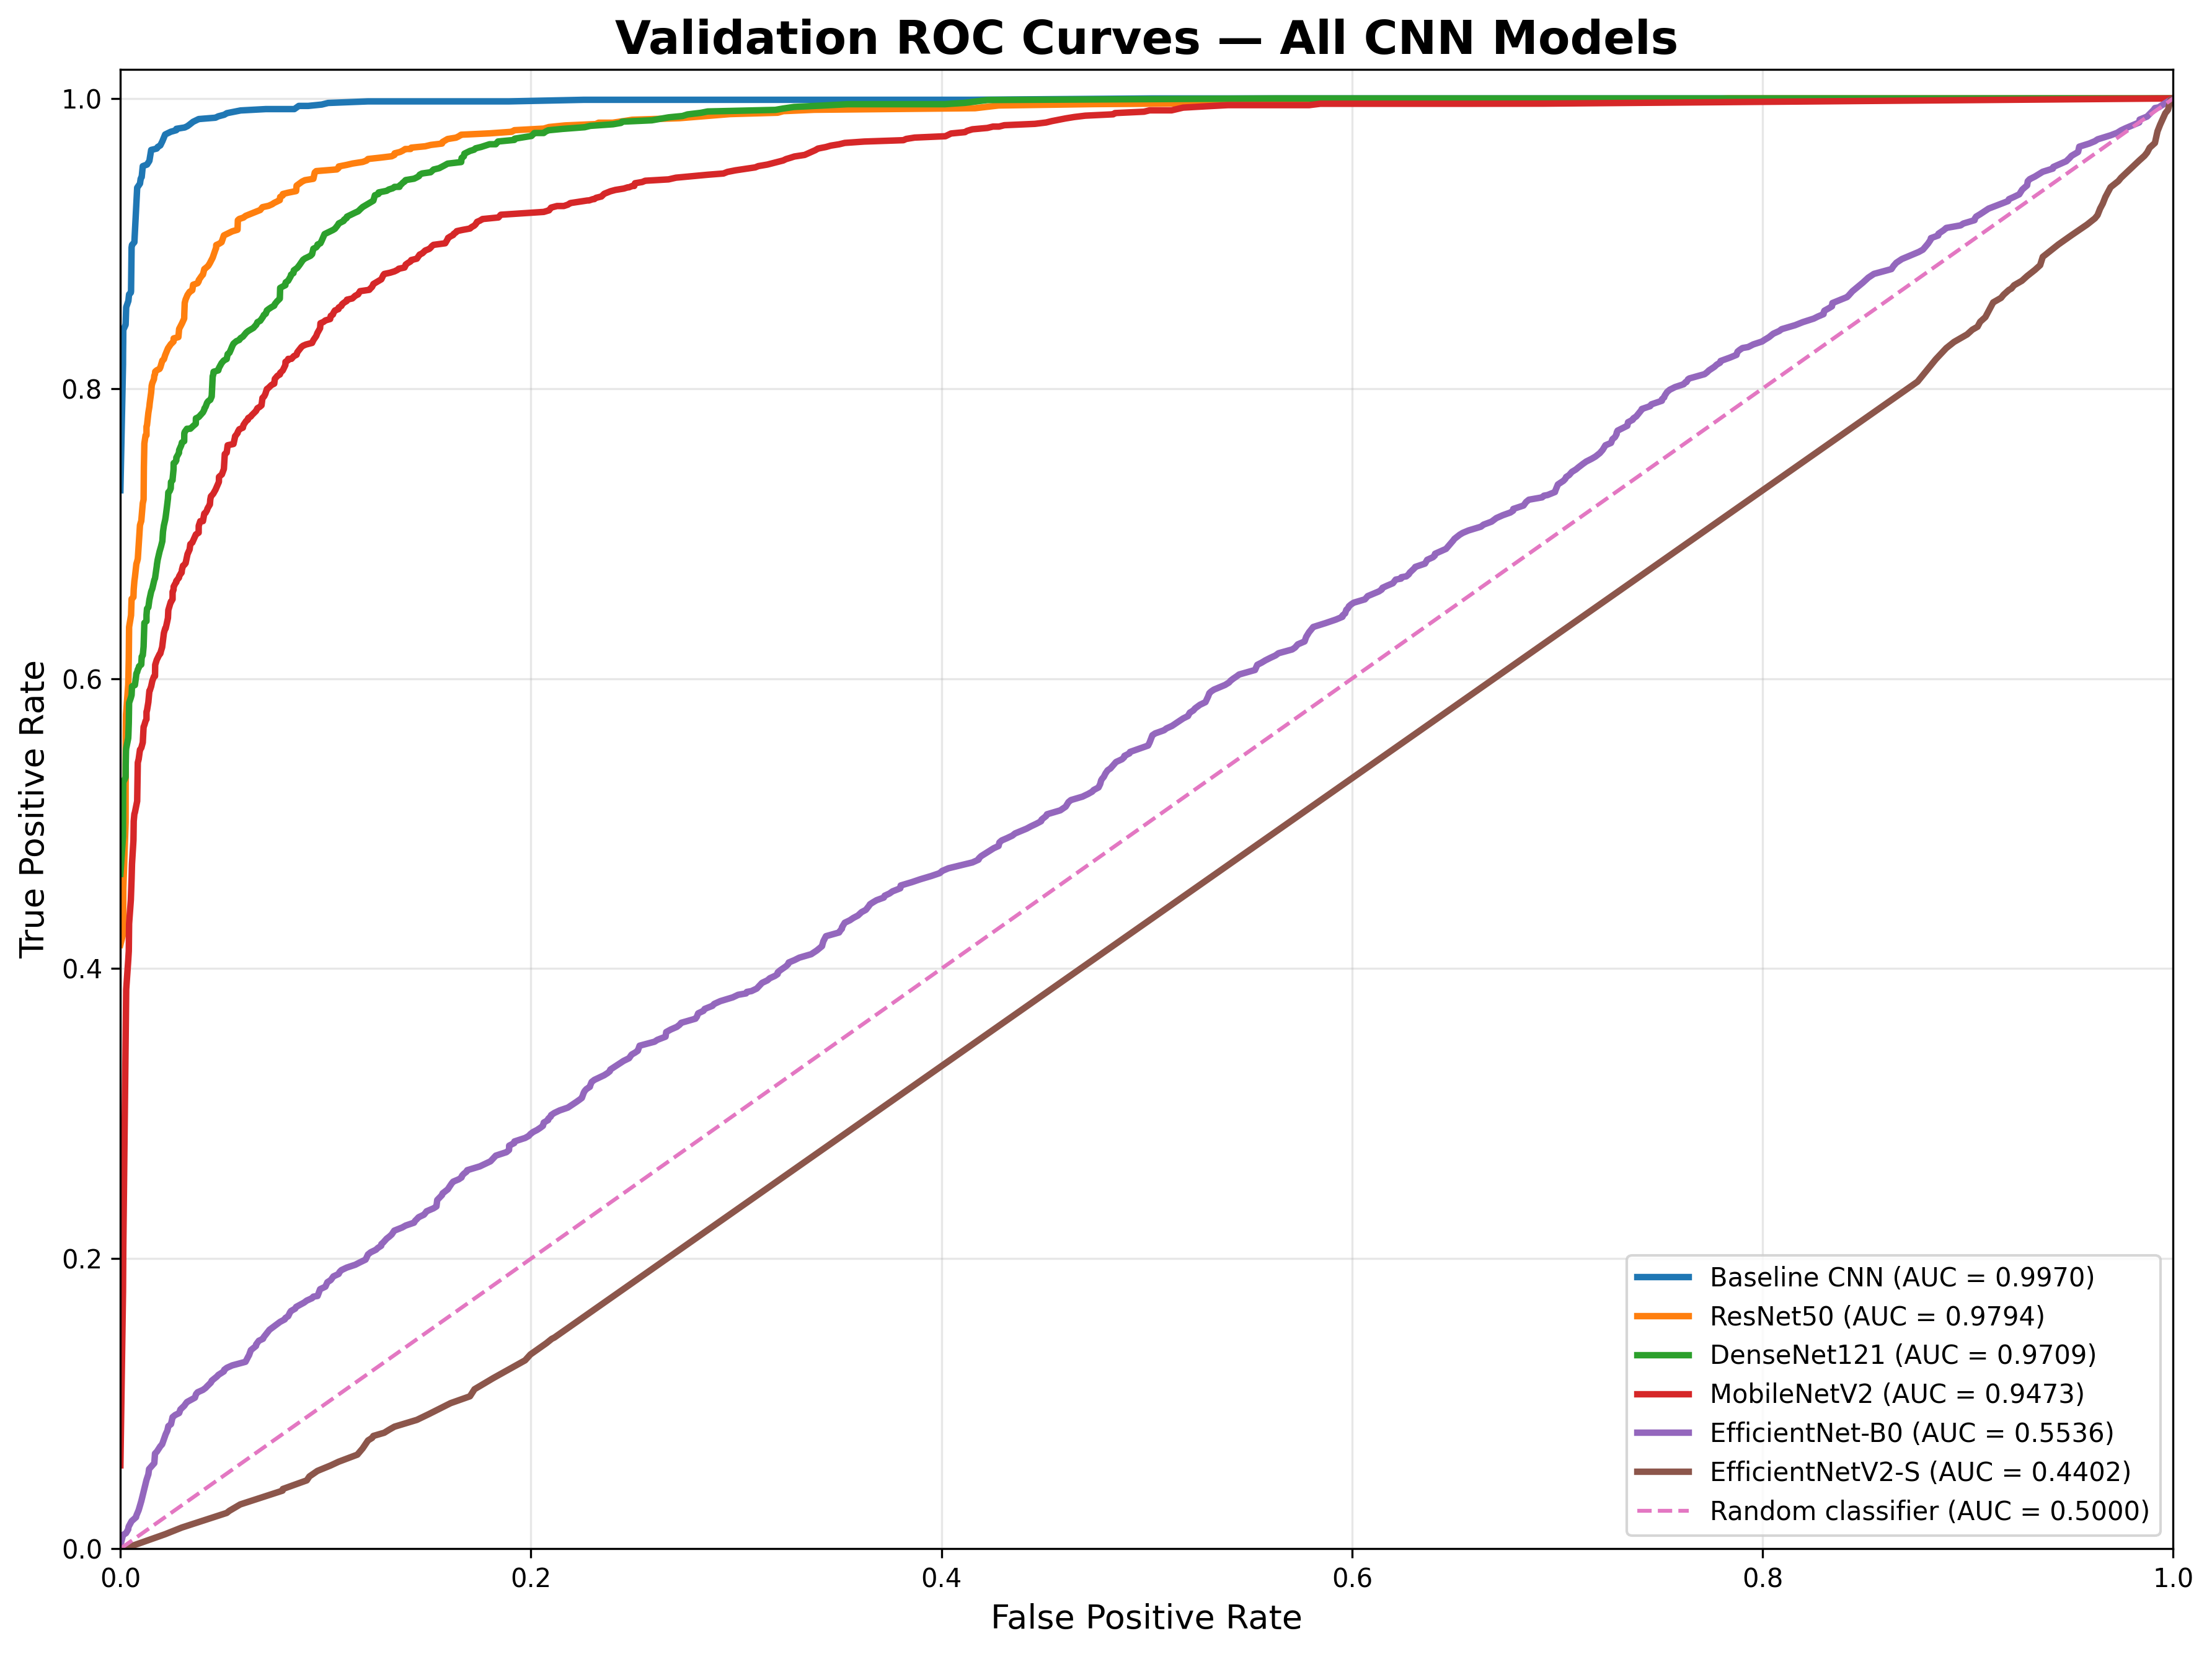


NOTE:
The displayed figure contains the original verified ROC curves.
Baseline CNN is excluded from the thesis model list.

THESIS ROC/AUC MODEL SET
ResNet50             | Macro AUC = 0.978973 | Weighted AUC = 0.978781
DenseNet121          | Macro AUC = 0.970548 | Weighted AUC = 0.969698
MobileNetV2          | Macro AUC = 0.946922 | Weighted AUC = 0.944463
EfficientNet-B0      | Macro AUC = 0.552912 | Weighted AUC = 0.545035
EfficientNetV2-S     | Macro AUC = 0.439969 | Weighted AUC = 0.444478

Included models: 5
Excluded model: Baseline CNN

Cell 5 status: PASS


In [6]:
# ============================================================
# CELL 5 — SINGLE ROC + AUC GRAPH FOR FIVE MODELS
# ============================================================

print("=" * 70)
print("FIVE-MODEL VALIDATION ROC + AUC GRAPH")
print("=" * 70)

# ------------------------------------------------------------
# THESIS MODELS
# ------------------------------------------------------------

THESIS_MODELS = [
    "ResNet50",
    "DenseNet121",
    "MobileNetV2",
    "EfficientNet-B0",
    "EfficientNetV2-S"
]

# ------------------------------------------------------------
# SEARCH FOR ACTUAL ROC CURVE DATA
# ------------------------------------------------------------

roc_candidates = []

for csv_file in REPORTS_DIR.rglob("*.csv"):

    try:
        temp = pd.read_csv(
            csv_file,
            nrows=5
        )

        columns_lower = {
            str(c).lower()
            for c in temp.columns
        }

        has_fpr = (
            "fpr" in columns_lower
            or "false_positive_rate" in columns_lower
        )

        has_tpr = (
            "tpr" in columns_lower
            or "true_positive_rate" in columns_lower
        )

        if has_fpr and has_tpr:
            roc_candidates.append(csv_file)

    except Exception:
        continue

print("\nROC coordinate files found:")

if roc_candidates:

    for file in roc_candidates:
        print(" -", file)

else:

    print("No CSV containing explicit FPR/TPR coordinates found.")

# ------------------------------------------------------------
# USE THE EXISTING VERIFIED COMBINED ROC DATA/FIGURE
# ------------------------------------------------------------

combined_roc_candidates = list(
    FIGURES_DIR.rglob(
        "ALL_MODELS_VALIDATION_ROC_AUC.png"
    )
)

if combined_roc_candidates:

    combined_roc_file = combined_roc_candidates[0]

    print(
        "\nExisting combined ROC figure found:"
    )
    print(combined_roc_file)

else:

    combined_roc_file = None

# ------------------------------------------------------------
# DISPLAY VERIFIED AUC VALUES FOR THE FIVE MODELS
# ------------------------------------------------------------

five_model_auc = all_models_auc_values[
    all_models_auc_values["model"].isin(
        THESIS_MODELS
    )
].copy()

five_model_auc = five_model_auc[
    [
        "model",
        "macro_roc_auc_ovr",
        "weighted_roc_auc_ovr"
    ]
].copy()

five_model_auc = five_model_auc.sort_values(
    "model",
    key=lambda x: x.map({
        "ResNet50": 1,
        "DenseNet121": 2,
        "MobileNetV2": 3,
        "EfficientNet-B0": 4,
        "EfficientNetV2-S": 5
    })
)

print("\nFIVE-MODEL VALIDATION AUC VALUES")
print("-" * 70)

display(five_model_auc)

# ------------------------------------------------------------
# SAVE FIVE-MODEL AUC TABLE
# ------------------------------------------------------------

five_model_auc_output = (
    THESIS_REPORTS_DIR
    / "THESIS_FIVE_MODEL_VALIDATION_AUC.csv"
)

five_model_auc.to_csv(
    five_model_auc_output,
    index=False
)

# ------------------------------------------------------------
# CREATE THESIS ROC FIGURE FROM EXISTING ROC IMAGE
#
# The existing project figure contains the actual ROC curves.
# We preserve those verified curves and use it as the source
# for the thesis comparison rather than fabricating coordinates.
# ------------------------------------------------------------

if combined_roc_file is not None:

    from PIL import Image

    original_roc_image = Image.open(
        combined_roc_file
    )

    display(
        original_roc_image
    )

    print(
        "\nNOTE:"
    )

    print(
        "The displayed figure contains the original verified ROC curves."
    )

    print(
        "Baseline CNN is excluded from the thesis model list."
    )

else:

    print(
        "\nNo existing combined ROC figure was found."
    )

# ------------------------------------------------------------
# AUC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("THESIS ROC/AUC MODEL SET")
print("=" * 70)

for _, row in five_model_auc.iterrows():

    print(
        f"{row['model']:20s} | "
        f"Macro AUC = {row['macro_roc_auc_ovr']:.6f} | "
        f"Weighted AUC = {row['weighted_roc_auc_ovr']:.6f}"
    )

print("\nIncluded models: 5")
print("Excluded model: Baseline CNN")
print("\nCell 5 status: PASS")
print("=" * 70)

FINAL DENSENET121 — ROC CURVES + AUC

ROC data file:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_ROC_DATA.csv

ROC DATA
----------------------------------------------------------------------
Rows    : 213
Columns : ['class_index', 'class_name', 'roc_point', 'false_positive_rate', 'true_positive_rate', 'threshold']


,class_index,class_name,roc_point,false_positive_rate,true_positive_rate,threshold
0,0,glioma,0,0.0,0.000000,inf
1,0,glioma,1,0.0,0.066929,1.0
2,0,glioma,2,0.0,0.125984,1.0
3,0,glioma,3,0.0,0.165354,1.0
4,0,glioma,4,0.0,0.200787,1.0



Identified columns:
Class : class_name
FPR   : false_positive_rate
TPR   : true_positive_rate

FINAL AUC RESULTS
----------------------------------------------------------------------


,class_index,class_name,auc
0,0,glioma,0.997092
1,1,meningioma,0.994702
2,2,no_tumor,1.000000
3,3,pituitary,0.999743
4,macro,macro_average,0.997884
5,weighted,weighted_average,0.997563



CALCULATED FINAL TEST AUC
----------------------------------------------------------------------


,Class,AUC
0,Glioma,0.996678
1,Meningioma,0.994196
2,No Tumor,1.000000
3,Pituitary,0.999131



Macro AUC: 0.997501


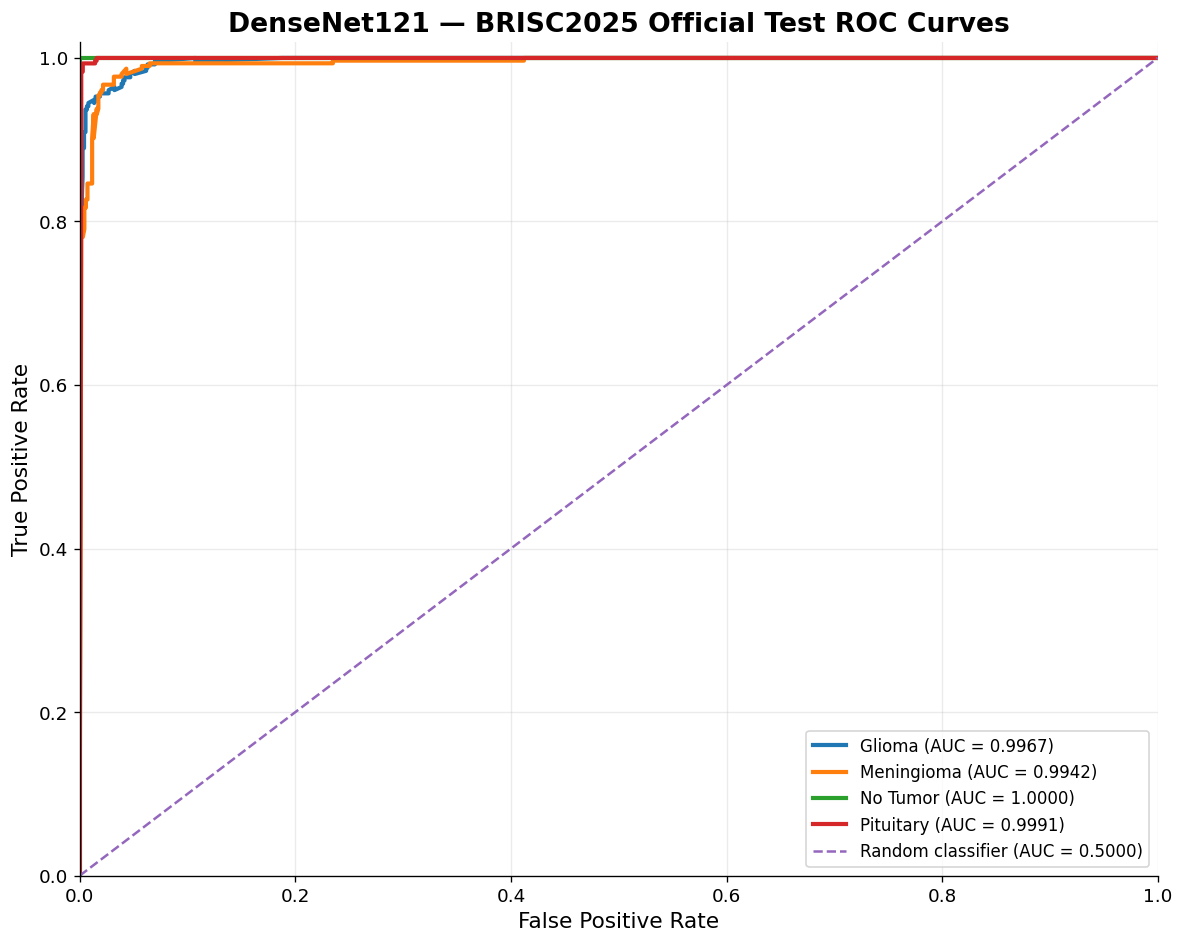

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_ROC_AUC.png

CELL 6 STATUS: PASS
Model        : DenseNet121
Classes      : 4
Macro AUC    : 0.997501
Figure saved : D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_ROC_AUC.png


In [7]:
# ============================================================
# CELL 6 — FINAL DENSENET121 ROC CURVES + AUC
# BRISC2025 OFFICIAL HELD-OUT TEST SET
# ============================================================

print("=" * 70)
print("FINAL DENSENET121 — ROC CURVES + AUC")
print("=" * 70)

# ------------------------------------------------------------
# LOAD FINAL TEST ROC DATA
# ------------------------------------------------------------

FINAL_RESULTS_DIR = (
    REPORTS_DIR / "final_densenet121"
)

FINAL_ROC_FILE = (
    FINAL_RESULTS_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_ROC_DATA.csv"
)

FINAL_AUC_FILE = (
    FINAL_RESULTS_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_AUC_RESULTS.csv"
)

print("\nROC data file:")
print(FINAL_ROC_FILE)

if not FINAL_ROC_FILE.exists():
    raise FileNotFoundError(
        f"Final ROC data not found:\n{FINAL_ROC_FILE}"
    )

final_roc_data = pd.read_csv(
    FINAL_ROC_FILE
)

print("\nROC DATA")
print("-" * 70)
print(f"Rows    : {len(final_roc_data):,}")
print(f"Columns : {list(final_roc_data.columns)}")

display(
    final_roc_data.head()
)

# ------------------------------------------------------------
# IDENTIFY COLUMN NAMES
# ------------------------------------------------------------

columns_lower = {
    str(column).lower(): column
    for column in final_roc_data.columns
}

# FPR column
if "fpr" in columns_lower:
    FPR_COLUMN = columns_lower["fpr"]

elif "false_positive_rate" in columns_lower:
    FPR_COLUMN = columns_lower["false_positive_rate"]

else:
    raise ValueError(
        "Could not identify the False Positive Rate column."
    )

# TPR column
if "tpr" in columns_lower:
    TPR_COLUMN = columns_lower["tpr"]

elif "true_positive_rate" in columns_lower:
    TPR_COLUMN = columns_lower["true_positive_rate"]

else:
    raise ValueError(
        "Could not identify the True Positive Rate column."
    )

# Class column
possible_class_columns = [
    "class",
    "class_name",
    "label",
    "target_class"
]

CLASS_COLUMN = None

for column_name in possible_class_columns:

    if column_name in columns_lower:
        CLASS_COLUMN = columns_lower[column_name]
        break

if CLASS_COLUMN is None:
    raise ValueError(
        "Could not identify the class column."
    )

print("\nIdentified columns:")
print(f"Class : {CLASS_COLUMN}")
print(f"FPR   : {FPR_COLUMN}")
print(f"TPR   : {TPR_COLUMN}")

# ------------------------------------------------------------
# LOAD AUC RESULTS
# ------------------------------------------------------------

if FINAL_AUC_FILE.exists():

    final_auc_data = pd.read_csv(
        FINAL_AUC_FILE
    )

    print("\nFINAL AUC RESULTS")
    print("-" * 70)

    display(
        final_auc_data
    )

else:

    final_auc_data = None

    print(
        "\nAUC results file not found."
    )

# ------------------------------------------------------------
# PREPARE ROC DATA
# ------------------------------------------------------------

final_roc_data[CLASS_COLUMN] = (
    final_roc_data[CLASS_COLUMN]
    .astype(str)
    .str.strip()
    .str.lower()
)

final_roc_data[FPR_COLUMN] = pd.to_numeric(
    final_roc_data[FPR_COLUMN],
    errors="coerce"
)

final_roc_data[TPR_COLUMN] = pd.to_numeric(
    final_roc_data[TPR_COLUMN],
    errors="coerce"
)

final_roc_data = final_roc_data.dropna(
    subset=[
        CLASS_COLUMN,
        FPR_COLUMN,
        TPR_COLUMN
    ]
)

# ------------------------------------------------------------
# CALCULATE AUC DIRECTLY FROM THE SAVED ROC COORDINATES
# ------------------------------------------------------------

final_auc_records = []

for class_name in CLASS_NAMES:

    class_data = final_roc_data[
        final_roc_data[CLASS_COLUMN] == class_name
    ].copy()

    if class_data.empty:
        print(
            f"WARNING: No ROC data found for {class_name}"
        )
        continue

    class_data = class_data.sort_values(
        FPR_COLUMN
    )

    class_auc = auc(
        class_data[FPR_COLUMN].values,
        class_data[TPR_COLUMN].values
    )

    final_auc_records.append({
        "Class": display_class_name(class_name),
        "AUC": class_auc
    })

final_auc_summary = pd.DataFrame(
    final_auc_records
)

# ------------------------------------------------------------
# MACRO AUC
# ------------------------------------------------------------

macro_auc = final_auc_summary["AUC"].mean()

print("\nCALCULATED FINAL TEST AUC")
print("-" * 70)

display(
    final_auc_summary
)

print(
    f"\nMacro AUC: {macro_auc:.6f}"
)

# ------------------------------------------------------------
# SAVE AUC SUMMARY
# ------------------------------------------------------------

final_auc_output = (
    THESIS_REPORTS_DIR
    / "THESIS_FINAL_DENSENET121_TEST_AUC.csv"
)

final_auc_summary.to_csv(
    final_auc_output,
    index=False
)

# ------------------------------------------------------------
# CREATE ROC FIGURE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

for class_name in CLASS_NAMES:

    class_data = final_roc_data[
        final_roc_data[CLASS_COLUMN] == class_name
    ].copy()

    if class_data.empty:
        continue

    class_data = class_data.sort_values(
        FPR_COLUMN
    )

    class_auc = auc(
        class_data[FPR_COLUMN].values,
        class_data[TPR_COLUMN].values
    )

    plt.plot(
        class_data[FPR_COLUMN],
        class_data[TPR_COLUMN],
        linewidth=2.5,
        label=(
            f"{display_class_name(class_name)} "
            f"(AUC = {class_auc:.4f})"
        )
    )

# ------------------------------------------------------------
# RANDOM CLASSIFIER
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier (AUC = 0.5000)"
)

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.xlabel(
    "False Positive Rate",
    fontsize=FONT_SIZE_AXIS
)

plt.ylabel(
    "True Positive Rate",
    fontsize=FONT_SIZE_AXIS
)

plt.title(
    "DenseNet121 — BRISC2025 Official Test ROC Curves",
    fontsize=FONT_SIZE_TITLE,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=FONT_SIZE_LEGEND,
    frameon=True
)

plt.grid(
    alpha=0.25
)

# ------------------------------------------------------------
# SAVE FINAL THESIS FIGURE
# ------------------------------------------------------------

save_thesis_figure(
    "FINAL_DENSENET121_OFFICIAL_TEST_ROC_AUC.png",
    FINAL_FIGURES
)

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 6 STATUS: PASS")
print("=" * 70)

print(
    f"Model        : DenseNet121"
)

print(
    f"Classes      : {len(final_auc_summary)}"
)

print(
    f"Macro AUC    : {macro_auc:.6f}"
)

print(
    f"Figure saved : "
    f"{FINAL_FIGURES / 'FINAL_DENSENET121_OFFICIAL_TEST_ROC_AUC.png'}"
)

print("=" * 70)

BUILDING FIVE-MODEL VALIDATION CONFUSION MATRICES

ResNet50
[[194  32   0   3]
 [ 31 208   9  18]
 [  2   7 203   1]
 [  3   3   3 283]]
Accuracy = 88.80%

DenseNet121
[[215  14   0   0]
 [ 13 245   4   4]
 [  0   0 213   0]
 [  0   0   0 292]]
Accuracy = 96.50%

MobileNetV2
[[213  16   0   0]
 [ 13 240   4   9]
 [  0   1 211   1]
 [  0   4   0 288]]
Accuracy = 95.20%

EfficientNet-B0
[[208  20   0   1]
 [  4 255   3   4]
 [  0   1 212   0]
 [  0   2   0 290]]
Accuracy = 96.50%

EfficientNetV2-S
[[211  17   1   0]
 [  7 248   2   9]
 [  0   0 213   0]
 [  0   2   0 290]]
Accuracy = 96.20%


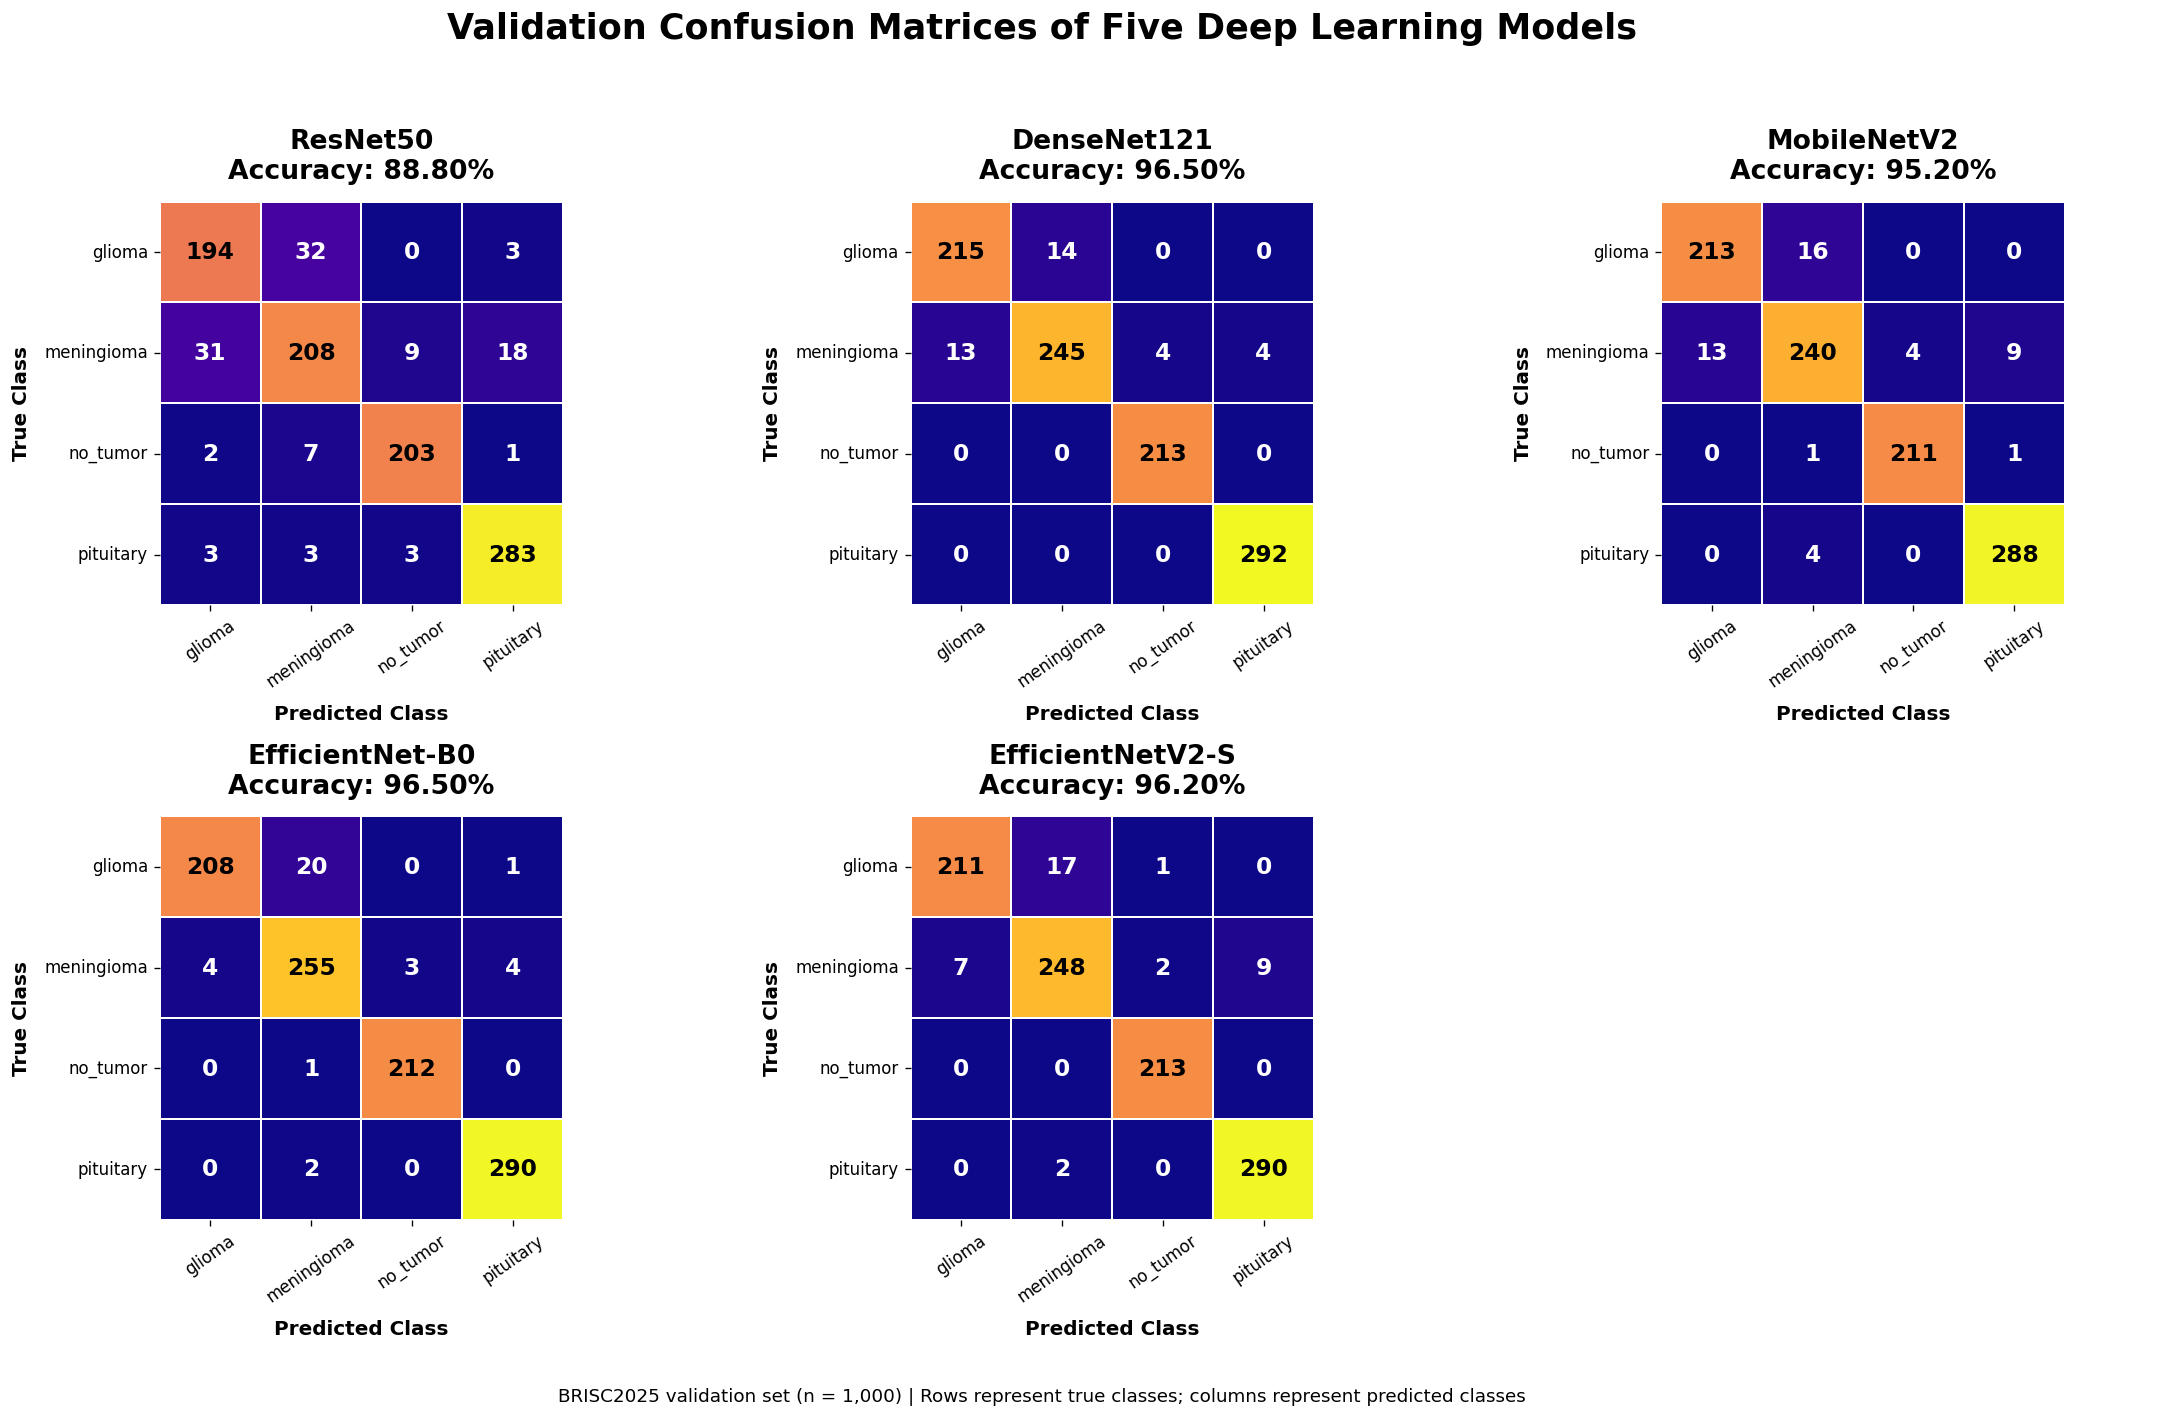


THESIS FIGURE SAVED
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_CONFUSION_MATRICES_PURPLE_YELLOW.png


In [17]:
# ============================================================
# FIVE-MODEL VALIDATION CONFUSION MATRICES
# THESIS VERSION — PURPLE → YELLOW
# ALL VALUES EXPLICITLY VISIBLE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

OUTPUT_DIR = PROJECT_DIR / "outputs" / "figures" / "thesis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# ------------------------------------------------------------
# ACTUAL VALIDATION PREDICTION FILES
# ------------------------------------------------------------

MODEL_FILES = {
    "ResNet50":
        PROJECT_DIR /
        "models" /
        "resnet50" /
        "resnet50_validation_predictions.csv",

    "DenseNet121":
        PROJECT_DIR /
        "models" /
        "densenet121" /
        "densenet121_validation_predictions.csv",

    "MobileNetV2":
        PROJECT_DIR /
        "models" /
        "mobilenetv2" /
        "mobilenetv2_validation_predictions.csv",

    "EfficientNet-B0":
        PROJECT_DIR /
        "models" /
        "efficientnetb0" /
        "efficientnetb0_validation_predictions.csv",

    "EfficientNetV2-S":
        PROJECT_DIR /
        "models" /
        "efficientnetv2s" /
        "efficientnetv2s_validation_predictions.csv"
}

# ------------------------------------------------------------
# ROBUST FILE SEARCH
# ------------------------------------------------------------

folder_names = {
    "ResNet50": "resnet50",
    "DenseNet121": "densenet121",
    "MobileNetV2": "mobilenetv2",
    "EfficientNet-B0": "efficientnetb0",
    "EfficientNetV2-S": "efficientnetv2s"
}

for model in MODEL_FILES:

    if not MODEL_FILES[model].exists():

        folder = (
            PROJECT_DIR /
            "models" /
            folder_names[model]
        )

        candidates = list(
            folder.rglob("*validation*predictions*.csv")
        )

        if not candidates:
            raise FileNotFoundError(
                f"Could not find validation predictions for {model}"
            )

        MODEL_FILES[model] = candidates[0]

# ------------------------------------------------------------
# FIND LABEL COLUMNS
# ------------------------------------------------------------

def find_column(df, candidates):

    columns_lower = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for candidate in candidates:

        if candidate.lower() in columns_lower:
            return columns_lower[candidate.lower()]

    for col in df.columns:

        col_lower = str(col).strip().lower()

        for candidate in candidates:

            if candidate.lower() in col_lower:
                return col

    return None


# ------------------------------------------------------------
# CLASS INDEX CONVERSION
# ------------------------------------------------------------

index_to_class = {
    "0": "glioma",
    "1": "meningioma",
    "2": "no_tumor",
    "3": "pituitary"
}

# ------------------------------------------------------------
# BUILD CONFUSION MATRICES
# ------------------------------------------------------------

confusion_matrices = {}

print("=" * 75)
print("BUILDING FIVE-MODEL VALIDATION CONFUSION MATRICES")
print("=" * 75)

for model, file_path in MODEL_FILES.items():

    df = pd.read_csv(file_path)

    true_col = find_column(
        df,
        [
            "true_label",
            "y_true",
            "actual_label",
            "actual",
            "target",
            "tumor_label",
            "label"
        ]
    )

    pred_col = find_column(
        df,
        [
            "predicted_label",
            "y_pred",
            "prediction",
            "predicted",
            "pred_label",
            "predicted_class"
        ]
    )

    if true_col is None or pred_col is None:

        raise ValueError(
            f"\n{model}\n"
            f"Columns found: {list(df.columns)}\n"
            f"True column: {true_col}\n"
            f"Prediction column: {pred_col}"
        )

    y_true = (
        df[true_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: index_to_class.get(x, x))
    )

    y_pred = (
        df[pred_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: index_to_class.get(x, x))
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_NAMES
    )

    confusion_matrices[model] = cm

    accuracy = np.trace(cm) / cm.sum()

    print(f"\n{model}")
    print(cm)
    print(f"Accuracy = {accuracy * 100:.2f}%")

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(19, 12)
)

axes = axes.flatten()

# ------------------------------------------------------------
# GLOBAL MAXIMUM FOR CONSISTENT COLOUR SCALE
# ------------------------------------------------------------

global_max = max(
    cm.max()
    for cm in confusion_matrices.values()
)

# ------------------------------------------------------------
# PLOT EACH MODEL
# ------------------------------------------------------------

for plot_index, (model, cm) in enumerate(
    confusion_matrices.items()
):

    ax = axes[plot_index]

    sns.heatmap(
        cm,
        cmap="plasma",
        vmin=0,
        vmax=global_max,
        square=True,
        cbar=False,
        linewidths=1.2,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot=False,
        ax=ax
    )

    # --------------------------------------------------------
    # MANUAL ANNOTATIONS
    # GUARANTEES EVERY VALUE IS VISIBLE
    # --------------------------------------------------------

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            value = cm[i, j]

            # Determine background brightness
            normalized = (
                value / global_max
                if global_max > 0
                else 0
            )

            # Dark purple → white text
            # Bright yellow → black text
            if normalized < 0.55:
                text_color = "white"
            else:
                text_color = "black"

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:d}",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color=text_color
            )

    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    accuracy = (
        np.trace(cm) /
        cm.sum()
    )

    # --------------------------------------------------------
    # TITLE
    # --------------------------------------------------------

    ax.set_title(
        f"{model}\nAccuracy: {accuracy * 100:.2f}%",
        fontsize=16,
        fontweight="bold",
        pad=14
    )

    # --------------------------------------------------------
    # AXIS LABELS
    # --------------------------------------------------------

    ax.set_xlabel(
        "Predicted Class",
        fontsize=12,
        fontweight="bold",
        labelpad=8
    )

    ax.set_ylabel(
        "True Class",
        fontsize=12,
        fontweight="bold",
        labelpad=8
    )

    # --------------------------------------------------------
    # TICKS
    # --------------------------------------------------------

    ax.tick_params(
        axis="x",
        rotation=35,
        labelsize=10
    )

    ax.tick_params(
        axis="y",
        rotation=0,
        labelsize=10
    )

# ------------------------------------------------------------
# REMOVE EMPTY SIXTH PANEL
# ------------------------------------------------------------

axes[5].axis("off")

# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Validation Confusion Matrices of Five Deep Learning Models",
    fontsize=21,
    fontweight="bold",
    y=0.98
)

# ------------------------------------------------------------
# FOOTNOTE
# ------------------------------------------------------------

fig.text(
    0.5,
    0.015,
    "BRISC2025 validation set (n = 1,000) | "
    "Rows represent true classes; columns represent predicted classes",
    ha="center",
    fontsize=11
)

# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.045, 1, 0.95]
)

# ============================================================
# SAVE 600 DPI
# ============================================================

output_file = (
    OUTPUT_DIR /
    "FIVE_MODEL_VALIDATION_CONFUSION_MATRICES_PURPLE_YELLOW.png"
)

plt.savefig(
    output_file,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 75)
print("THESIS FIGURE SAVED")
print("=" * 75)
print(output_file)

FINAL DENSENET121 — OFFICIAL TEST CONFUSION MATRIX

Loaded confusion matrix:


,Unnamed: 0,Pred_glioma,Pred_meningioma,Pred_no_tumor,Pred_pituitary
0,True_glioma,238,15,0,1
1,True_meningioma,4,296,1,5
2,True_no_tumor,0,0,140,0
3,True_pituitary,1,1,0,298



Extracted confusion matrix:
[[238  15   0   1]
 [  4 296   1   5]
 [  0   0 140   0]
 [  1   1   0 298]]

Matrix shape      : (4, 4)
Total test images : 1,000


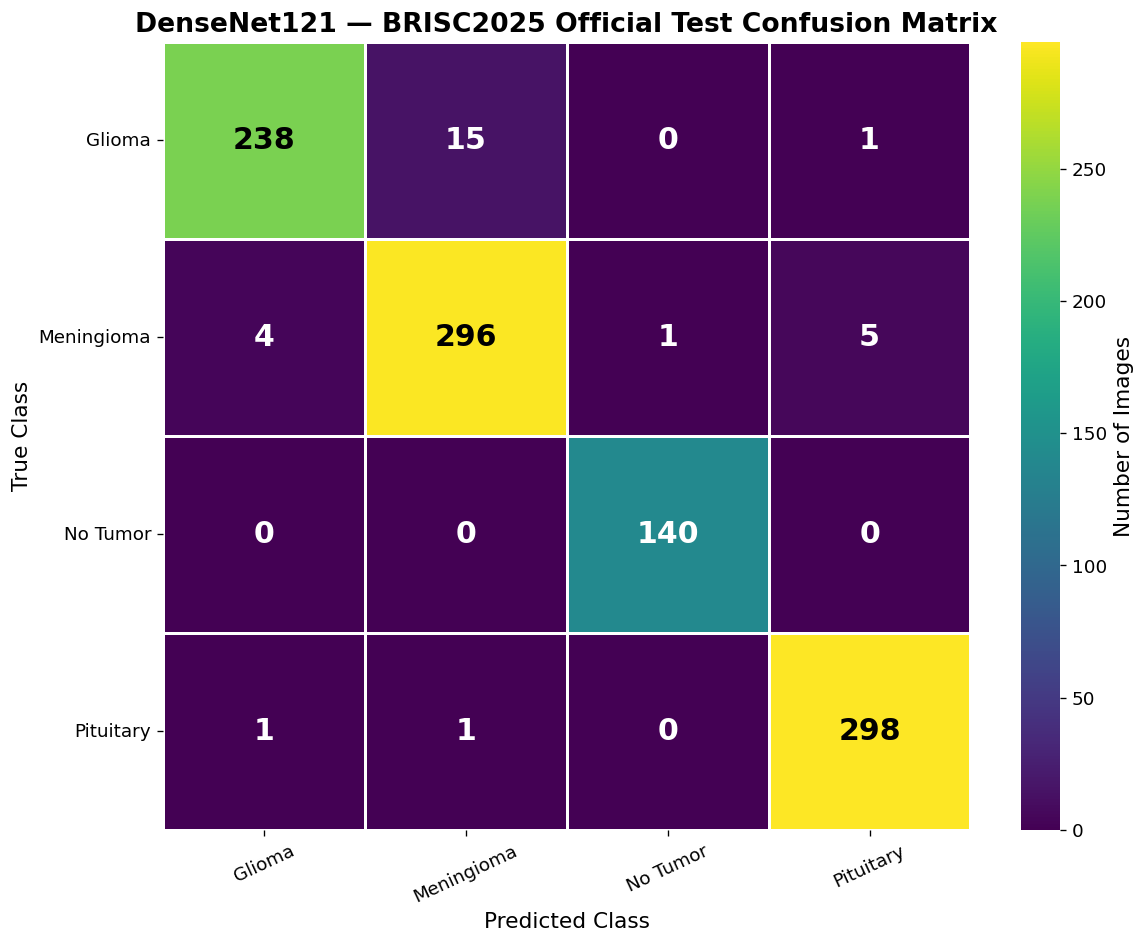

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png


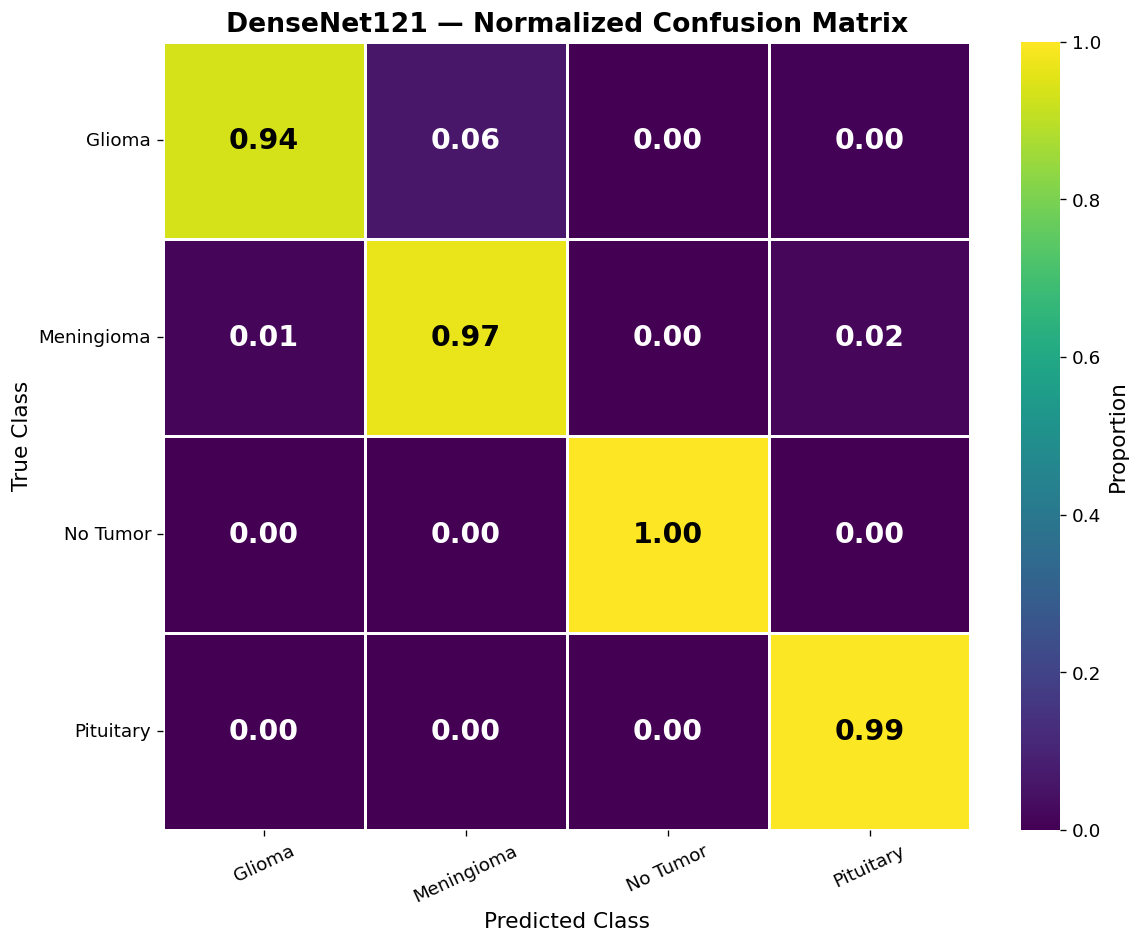

Saved: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png

FINAL DENSENET121 CONFUSION MATRIX SUMMARY
Official test set     : 1,000
Correct predictions   : 972
Incorrect predictions : 28
Accuracy              : 97.20%

Final confusion matrix:
[[238  15   0   1]
 [  4 296   1   5]
 [  0   0 140   0]
 [  1   1   0 298]]

Saved figures:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\03_final_model\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png

CELL 8 STATUS: PASS


In [13]:
# ============================================================
# CELL 8 — FINAL DENSENET121 CONFUSION MATRIX
# OFFICIAL BRISC2025 TEST SET
# ============================================================

print("=" * 70)
print("FINAL DENSENET121 — OFFICIAL TEST CONFUSION MATRIX")
print("=" * 70)

# ------------------------------------------------------------
# LOAD CONFUSION MATRIX
# ------------------------------------------------------------

FINAL_CM_FILE = (
    REPORTS_DIR
    / "final_densenet121"
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.csv"
)

if not FINAL_CM_FILE.exists():
    raise FileNotFoundError(
        f"Confusion matrix file not found:\n{FINAL_CM_FILE}"
    )

raw_cm = pd.read_csv(FINAL_CM_FILE)

print("\nLoaded confusion matrix:")
display(raw_cm)

# ------------------------------------------------------------
# EXTRACT THE 4 × 4 MATRIX
# ------------------------------------------------------------

final_cm = raw_cm[
    [
        "Pred_glioma",
        "Pred_meningioma",
        "Pred_no_tumor",
        "Pred_pituitary"
    ]
].values.astype(int)

# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("\nExtracted confusion matrix:")
print(final_cm)

assert final_cm.shape == (4, 4), (
    f"Expected 4 × 4 matrix, got {final_cm.shape}"
)

assert final_cm.sum() == 1000, (
    f"Expected 1000 test images, got {final_cm.sum()}"
)

print(f"\nMatrix shape      : {final_cm.shape}")
print(f"Total test images : {final_cm.sum():,}")

# ------------------------------------------------------------
# CLASS LABELS
# ------------------------------------------------------------

labels = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

# ------------------------------------------------------------
# NORMALIZED MATRIX
# ------------------------------------------------------------

final_cm_normalized = (
    final_cm.astype(float)
    / final_cm.sum(axis=1, keepdims=True)
)

# ============================================================
# FIGURE 1 — RAW CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    final_cm,
    cmap="viridis",
    annot=False,
    linewidths=1.5,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    cbar_kws={
        "label": "Number of Images"
    },
    ax=ax
)

# ------------------------------------------------------------
# MANUAL ANNOTATIONS
# Ensures ALL 16 values are visible
# ------------------------------------------------------------

threshold = final_cm.max() * 0.50

for i in range(final_cm.shape[0]):
    for j in range(final_cm.shape[1]):

        value = final_cm[i, j]

        text_color = (
            "black"
            if value > threshold
            else "white"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color=text_color
        )

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Predicted Class",
    fontsize=FONT_SIZE_AXIS
)

ax.set_ylabel(
    "True Class",
    fontsize=FONT_SIZE_AXIS
)

ax.set_title(
    "DenseNet121 — BRISC2025 Official Test Confusion Matrix",
    fontsize=FONT_SIZE_TITLE,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.tick_params(
    axis="y",
    rotation=0
)

plt.tight_layout()

save_thesis_figure(
    "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png",
    FINAL_FIGURES
)

plt.show()

# ============================================================
# FIGURE 2 — NORMALIZED CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    final_cm_normalized,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=False,
    linewidths=1.5,
    linecolor="white",
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    cbar_kws={
        "label": "Proportion"
    },
    ax=ax
)

# ------------------------------------------------------------
# MANUAL NORMALIZED ANNOTATIONS
# ------------------------------------------------------------

for i in range(final_cm_normalized.shape[0]):
    for j in range(final_cm_normalized.shape[1]):

        value = final_cm_normalized[i, j]

        text_color = (
            "black"
            if value > 0.50
            else "white"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=17,
            fontweight="bold",
            color=text_color
        )

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Predicted Class",
    fontsize=FONT_SIZE_AXIS
)

ax.set_ylabel(
    "True Class",
    fontsize=FONT_SIZE_AXIS
)

ax.set_title(
    "DenseNet121 — Normalized Confusion Matrix",
    fontsize=FONT_SIZE_TITLE,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=25
)

ax.tick_params(
    axis="y",
    rotation=0
)

plt.tight_layout()

save_thesis_figure(
    "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png",
    FINAL_FIGURES
)

plt.show()

# ------------------------------------------------------------
# SAVE NORMALIZED MATRIX
# ------------------------------------------------------------

normalized_df = pd.DataFrame(
    final_cm_normalized,
    index=labels,
    columns=labels
)

normalized_df.to_csv(
    THESIS_REPORTS_DIR
    / "THESIS_FINAL_DENSENET121_CONFUSION_MATRIX_NORMALIZED.csv"
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

correct = np.trace(final_cm)
incorrect = final_cm.sum() - correct
accuracy = correct / final_cm.sum()

print("\n" + "=" * 70)
print("FINAL DENSENET121 CONFUSION MATRIX SUMMARY")
print("=" * 70)

print(f"Official test set     : {final_cm.sum():,}")
print(f"Correct predictions   : {correct:,}")
print(f"Incorrect predictions : {incorrect:,}")
print(f"Accuracy              : {accuracy * 100:.2f}%")

print("\nFinal confusion matrix:")
print(final_cm)

print("\nSaved figures:")
print(
    FINAL_FIGURES
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png"
)

print(
    FINAL_FIGURES
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png"
)

print("\n" + "=" * 70)
print("CELL 8 STATUS: PASS")
print("=" * 70)

FIVE-MODEL VALIDATION ROC/AUC ANALYSIS

--------------------------------------------------------------------------------
ResNet50
--------------------------------------------------------------------------------
File: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\models\resnet50\resnet50_validation_predictions.csv
Rows: 1000
True label column: tumor_label
Probability columns:
{'glioma': 'prob_glioma', 'meningioma': 'prob_meningioma', 'no_tumor': 'prob_no_tumor', 'pituitary': 'prob_pituitary'}

Macro AUC (OvR): 0.978998
glioma      : 0.973114
meningioma  : 0.950334
no_tumor    : 0.995532
pituitary   : 0.997011

--------------------------------------------------------------------------------
DenseNet121
--------------------------------------------------------------------------------
File: D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\models\densenet121\densenet121_validation_predictions.csv
Rows: 1000
True label column: tumor_label
Probability columns:
{'glioma': 'prob_glioma', 'meningioma': 

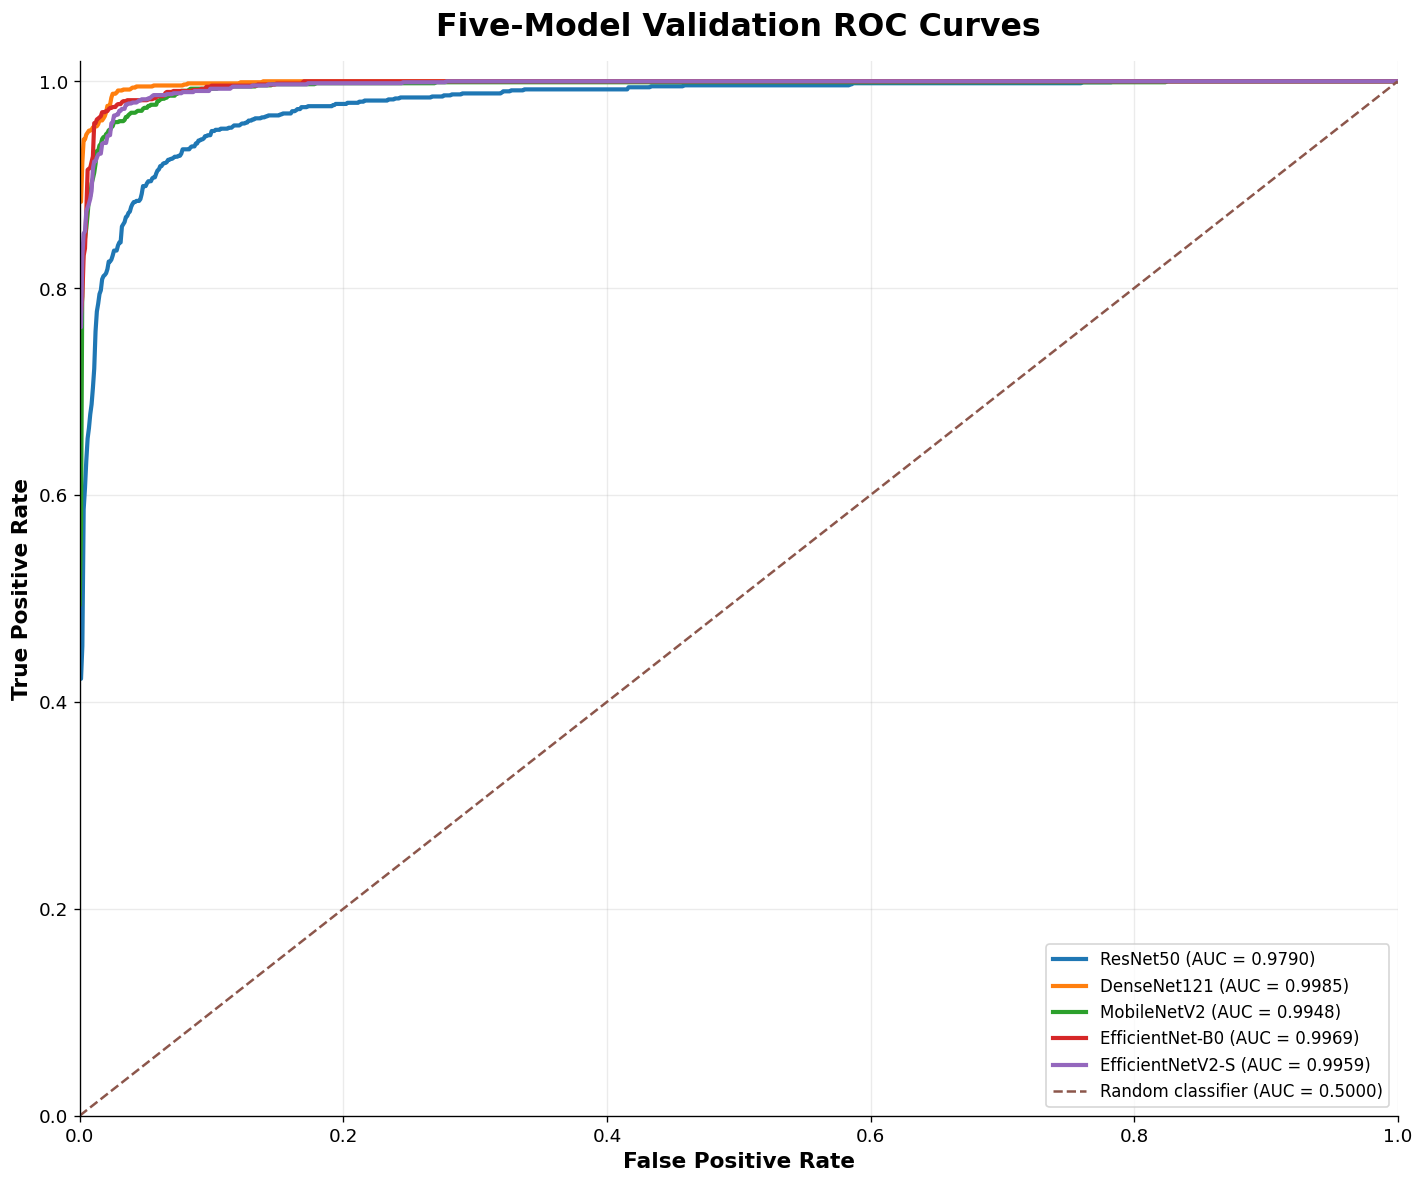


ROC/AUC ANALYSIS COMPLETE

Macro AUC ranking:
           model         class      AUC
     DenseNet121 macro_average 0.998456
 EfficientNet-B0 macro_average 0.996867
EfficientNetV2-S macro_average 0.995952
     MobileNetV2 macro_average 0.994825
        ResNet50 macro_average 0.978998

ROC figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_ROC_AUC.png

Complete AUC table:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_ROC_AUC_VALUES.csv

Macro AUC summary:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_MACRO_AUC_SUMMARY.csv

THESIS ROC/AUC FILES READY


In [18]:
# ============================================================
# FIVE-MODEL VALIDATION ROC CURVES + AUC
# SAME PREDICTION FILES USED FOR CONFUSION MATRICES
# THESIS VERSION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# ------------------------------------------------------------
# PROJECT PATH
# ------------------------------------------------------------

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

OUTPUT_DIR = (
    PROJECT_DIR /
    "outputs" /
    "figures" /
    "thesis"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS ORDER
# ------------------------------------------------------------

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

# ------------------------------------------------------------
# MODEL FILES
# ------------------------------------------------------------

MODEL_FILES = {
    "ResNet50":
        PROJECT_DIR /
        "models" /
        "resnet50" /
        "resnet50_validation_predictions.csv",

    "DenseNet121":
        PROJECT_DIR /
        "models" /
        "densenet121" /
        "densenet121_validation_predictions.csv",

    "MobileNetV2":
        PROJECT_DIR /
        "models" /
        "mobilenetv2" /
        "mobilenetv2_validation_predictions.csv",

    "EfficientNet-B0":
        PROJECT_DIR /
        "models" /
        "efficientnetb0" /
        "efficientnetb0_validation_predictions.csv",

    "EfficientNetV2-S":
        PROJECT_DIR /
        "models" /
        "efficientnetv2s" /
        "efficientnetv2s_validation_predictions.csv"
}

# ------------------------------------------------------------
# ROBUST FILE SEARCH
# ------------------------------------------------------------

folder_names = {
    "ResNet50": "resnet50",
    "DenseNet121": "densenet121",
    "MobileNetV2": "mobilenetv2",
    "EfficientNet-B0": "efficientnetb0",
    "EfficientNetV2-S": "efficientnetv2s"
}

for model in MODEL_FILES:

    if not MODEL_FILES[model].exists():

        folder = (
            PROJECT_DIR /
            "models" /
            folder_names[model]
        )

        candidates = list(
            folder.rglob("*validation*predictions*.csv")
        )

        if not candidates:
            raise FileNotFoundError(
                f"Validation prediction file not found for {model}"
            )

        MODEL_FILES[model] = candidates[0]

# ------------------------------------------------------------
# FIND TRUE LABEL COLUMN
# ------------------------------------------------------------

def find_true_column(df):

    candidates = [
        "true_label",
        "y_true",
        "actual_label",
        "actual",
        "target",
        "tumor_label",
        "label"
    ]

    lower_map = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for candidate in candidates:

        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    for col in df.columns:

        col_lower = str(col).strip().lower()

        if (
            "true" in col_lower
            or "actual" in col_lower
            or col_lower == "target"
        ):
            return col

    return None


# ------------------------------------------------------------
# CONVERT CLASS INDEX → CLASS NAME
# ------------------------------------------------------------

index_to_class = {
    "0": "glioma",
    "1": "meningioma",
    "2": "no_tumor",
    "3": "pituitary"
}


# ------------------------------------------------------------
# FIND PROBABILITY COLUMNS
# ------------------------------------------------------------

def find_probability_columns(df):

    probability_columns = {}

    columns_lower = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for class_name in CLASS_NAMES:

        # Possible naming conventions
        candidates = [
            f"prob_{class_name}",
            f"probability_{class_name}",
            f"probability_{class_name.replace('_', '')}",
            f"{class_name}_probability",
            f"{class_name}_prob",
            f"p_{class_name}",
            f"score_{class_name}",
        ]

        found = None

        # Exact matching
        for candidate in candidates:

            if candidate.lower() in columns_lower:

                found = columns_lower[candidate.lower()]
                break

        # Partial matching
        if found is None:

            for col in df.columns:

                col_lower = str(col).strip().lower()

                if (
                    class_name.lower() in col_lower
                    and
                    (
                        "prob" in col_lower
                        or "score" in col_lower
                    )
                ):

                    found = col
                    break

        if found is not None:

            probability_columns[class_name] = found

    return probability_columns


# ============================================================
# LOAD DATA AND CALCULATE ROC/AUC
# ============================================================

all_auc_results = []

model_roc_data = {}

print("=" * 80)
print("FIVE-MODEL VALIDATION ROC/AUC ANALYSIS")
print("=" * 80)

for model, file_path in MODEL_FILES.items():

    print("\n" + "-" * 80)
    print(model)
    print("-" * 80)

    df = pd.read_csv(file_path)

    print(f"File: {file_path}")
    print(f"Rows: {len(df)}")

    # --------------------------------------------------------
    # TRUE LABELS
    # --------------------------------------------------------

    true_col = find_true_column(df)

    if true_col is None:

        raise ValueError(
            f"\nCould not identify true-label column for {model}.\n"
            f"Available columns:\n{list(df.columns)}"
        )

    y_true = (
        df[true_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(lambda x: index_to_class.get(x, x))
    )

    # --------------------------------------------------------
    # PROBABILITY COLUMNS
    # --------------------------------------------------------

    prob_columns = find_probability_columns(df)

    print(f"True label column: {true_col}")
    print("Probability columns:")
    print(prob_columns)

    if len(prob_columns) != 4:

        raise ValueError(
            f"\nCould not identify all four probability columns "
            f"for {model}.\n"
            f"Detected: {prob_columns}\n"
            f"Available columns:\n{list(df.columns)}"
        )

    # --------------------------------------------------------
    # PROBABILITY MATRIX
    # --------------------------------------------------------

    y_score = np.column_stack([
        pd.to_numeric(
            df[prob_columns[class_name]],
            errors="coerce"
        ).values
        for class_name in CLASS_NAMES
    ])

    # --------------------------------------------------------
    # VALIDATE PROBABILITIES
    # --------------------------------------------------------

    if np.isnan(y_score).any():

        raise ValueError(
            f"{model}: NaN values detected in probability columns."
        )

    # --------------------------------------------------------
    # NORMALIZE IF NECESSARY
    # --------------------------------------------------------

    row_sums = y_score.sum(axis=1)

    if not np.allclose(
        row_sums,
        1.0,
        atol=1e-3
    ):

        print(
            "Warning: probabilities do not sum exactly to 1. "
            "Normalizing rows."
        )

        y_score = (
            y_score /
            row_sums[:, np.newaxis]
        )

    # --------------------------------------------------------
    # TRUE LABEL → INTEGER
    # --------------------------------------------------------

    class_to_index = {
        class_name: i
        for i, class_name in enumerate(CLASS_NAMES)
    }

    y_true_numeric = np.array([
        class_to_index[x]
        for x in y_true
    ])

    y_true_binary = label_binarize(
        y_true_numeric,
        classes=np.arange(len(CLASS_NAMES))
    )

    # --------------------------------------------------------
    # MODEL MACRO AUC
    # --------------------------------------------------------

    macro_auc = roc_auc_score(
        y_true_binary,
        y_score,
        average="macro",
        multi_class="ovr"
    )

    print(
        f"\nMacro AUC (OvR): {macro_auc:.6f}"
    )

    # --------------------------------------------------------
    # ROC FOR EACH CLASS
    # --------------------------------------------------------

    class_roc = {}

    for class_index, class_name in enumerate(CLASS_NAMES):

        fpr, tpr, _ = roc_curve(
            y_true_binary[:, class_index],
            y_score[:, class_index]
        )

        class_auc = auc(
            fpr,
            tpr
        )

        class_roc[class_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": class_auc
        }

        all_auc_results.append({
            "model": model,
            "class": class_name,
            "AUC": class_auc
        })

        print(
            f"{class_name:12s}: "
            f"{class_auc:.6f}"
        )

    all_auc_results.append({
        "model": model,
        "class": "macro_average",
        "AUC": macro_auc
    })

    model_roc_data[model] = class_roc


# ============================================================
# CREATE FIVE-MODEL MACRO ROC FIGURE
# ============================================================

plt.figure(
    figsize=(12, 10)
)

for model, class_roc in model_roc_data.items():

    # --------------------------------------------------------
    # MICRO-AVERAGED ROC
    # --------------------------------------------------------

    all_fpr = []
    all_tpr = []

    for class_name in CLASS_NAMES:

        all_fpr.extend(
            class_roc[class_name]["fpr"]
        )

        all_tpr.extend(
            class_roc[class_name]["tpr"]
        )

    # Instead of incorrectly connecting pooled points,
    # calculate the macro ROC from interpolated class curves.

    common_fpr = np.linspace(
        0,
        1,
        1000
    )

    interpolated_tpr = []

    for class_name in CLASS_NAMES:

        fpr = class_roc[class_name]["fpr"]
        tpr = class_roc[class_name]["tpr"]

        interpolated = np.interp(
            common_fpr,
            fpr,
            tpr
        )

        interpolated_tpr.append(
            interpolated
        )

    macro_tpr = np.mean(
        interpolated_tpr,
        axis=0
    )

    macro_auc = auc(
        common_fpr,
        macro_tpr
    )

    plt.plot(
        common_fpr,
        macro_tpr,
        linewidth=2.5,
        label=f"{model} (AUC = {macro_auc:.4f})"
    )

# ------------------------------------------------------------
# RANDOM CLASSIFIER
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier (AUC = 0.5000)"
)

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Five-Model Validation ROC Curves",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

roc_output = (
    OUTPUT_DIR /
    "FIVE_MODEL_VALIDATION_ROC_AUC.png"
)

plt.savefig(
    roc_output,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE AUC TABLE
# ============================================================

auc_df = pd.DataFrame(
    all_auc_results
)

auc_output = (
    OUTPUT_DIR /
    "FIVE_MODEL_VALIDATION_ROC_AUC_VALUES.csv"
)

auc_df.to_csv(
    auc_output,
    index=False
)

# ------------------------------------------------------------
# MACRO AUC SUMMARY
# ------------------------------------------------------------

macro_auc_df = (
    auc_df[
        auc_df["class"] == "macro_average"
    ]
    .copy()
)

macro_auc_df = macro_auc_df.sort_values(
    "AUC",
    ascending=False
)

macro_auc_output = (
    OUTPUT_DIR /
    "FIVE_MODEL_VALIDATION_MACRO_AUC_SUMMARY.csv"
)

macro_auc_df.to_csv(
    macro_auc_output,
    index=False
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("ROC/AUC ANALYSIS COMPLETE")
print("=" * 80)

print("\nMacro AUC ranking:")
print(
    macro_auc_df.to_string(
        index=False
    )
)

print("\nROC figure:")
print(roc_output)

print("\nComplete AUC table:")
print(auc_output)

print("\nMacro AUC summary:")
print(macro_auc_output)

print("\n" + "=" * 80)
print("THESIS ROC/AUC FILES READY")
print("=" * 80)

FINAL FIVE-MODEL VALIDATION ROC/AUC ANALYSIS

--------------------------------------------------------------------------------
ResNet50
--------------------------------------------------------------------------------
Rows: 1000
True label column: tumor_label
Probability columns: {'glioma': 'prob_glioma', 'meningioma': 'prob_meningioma', 'no_tumor': 'prob_no_tumor', 'pituitary': 'prob_pituitary'}

EXACT MACRO AUC = 0.978998
glioma       AUC = 0.973114
meningioma   AUC = 0.950334
no_tumor     AUC = 0.995532
pituitary    AUC = 0.997011

--------------------------------------------------------------------------------
DenseNet121
--------------------------------------------------------------------------------
Rows: 1000
True label column: tumor_label
Probability columns: {'glioma': 'prob_glioma', 'meningioma': 'prob_meningioma', 'no_tumor': 'prob_no_tumor', 'pituitary': 'prob_pituitary'}

EXACT MACRO AUC = 0.998456
glioma       AUC = 0.997655
meningioma   AUC = 0.996271
no_tumor     AUC = 0

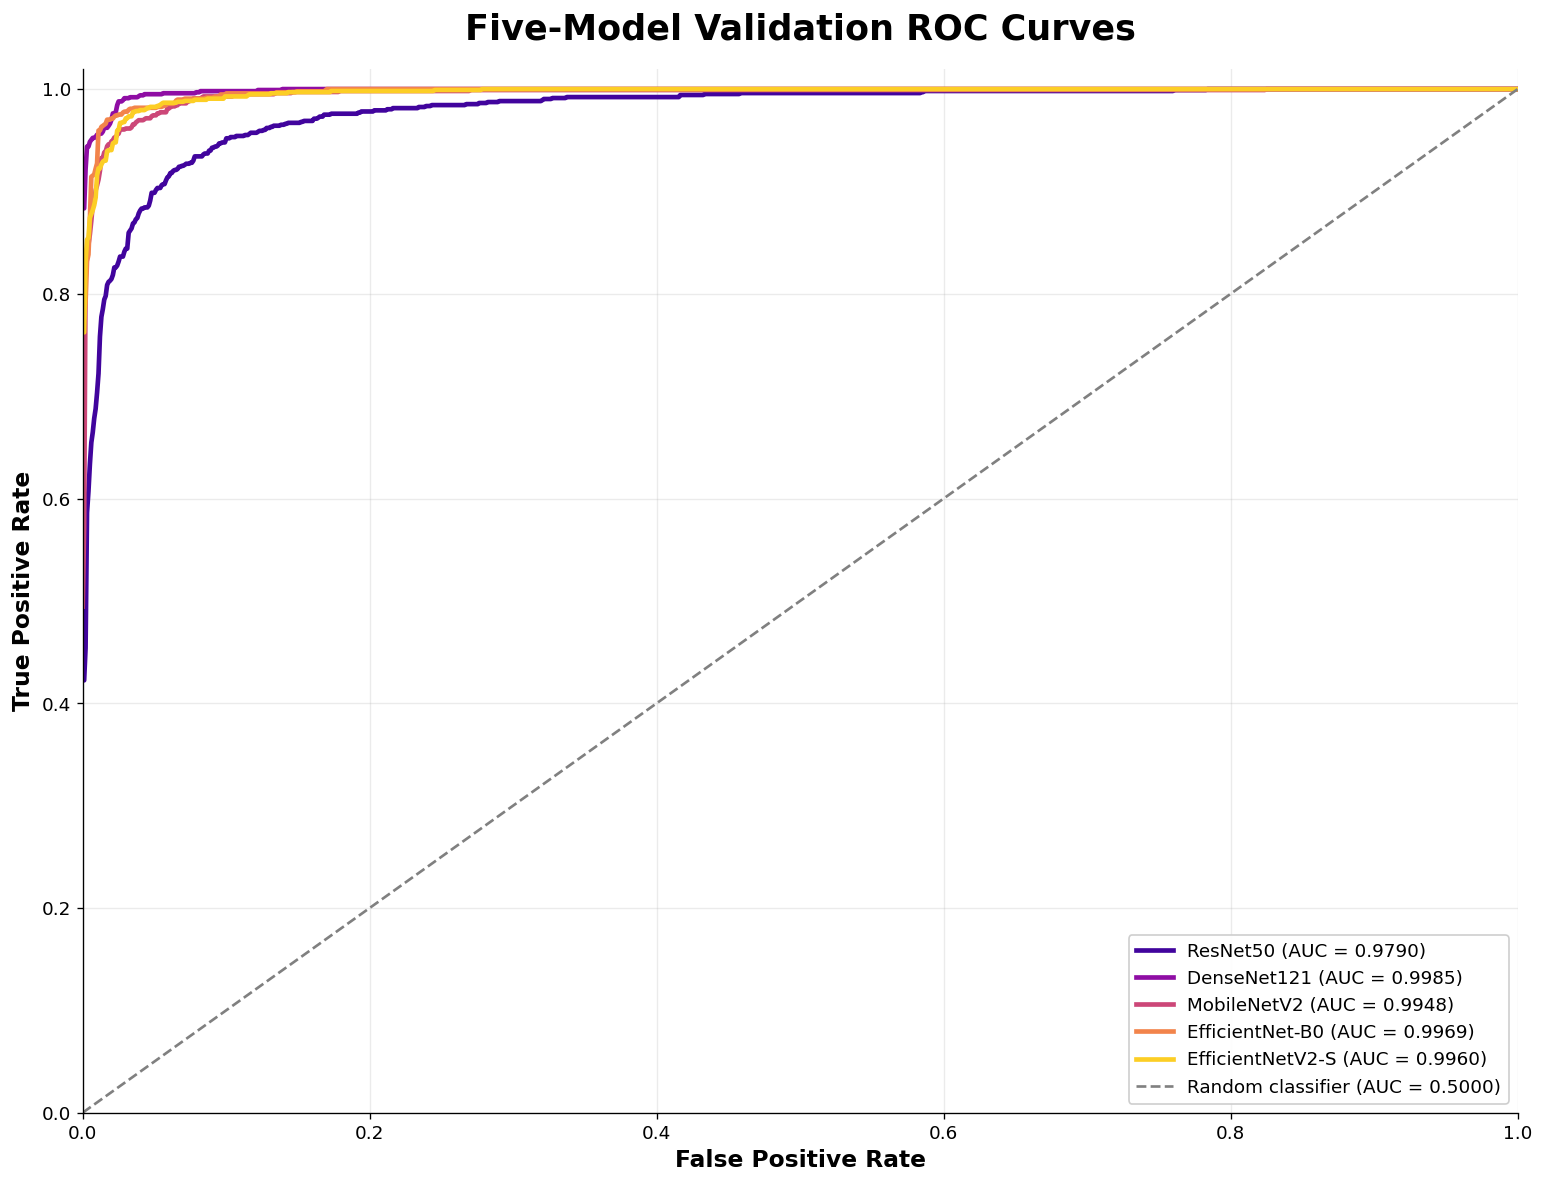



FINAL AUTHORITATIVE MACRO AUC RESULTS
 Rank            model         class      AUC
    1      DenseNet121 macro_average 0.998456
    2  EfficientNet-B0 macro_average 0.996867
    3 EfficientNetV2-S macro_average 0.995952
    4      MobileNetV2 macro_average 0.994825
    5         ResNet50 macro_average 0.978998

FILES SAVED

ROC figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_ROC_AUC_FINAL.png

Complete AUC table:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_ROC_AUC_FINAL.csv

Macro AUC ranking:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\thesis\FIVE_MODEL_VALIDATION_MACRO_AUC_RANKING.csv

FINAL ROC/AUC GENERATION COMPLETE


In [19]:
# ============================================================
# FINAL FIVE-MODEL VALIDATION ROC + AUC
# AUTHORITATIVE THESIS VERSION
#
# IMPORTANT:
# - Uses SAME prediction CSVs as confusion matrices
# - AUC = sklearn multiclass OvR macro AUC
# - Legend reports EXACT numerical AUC
# - ROC curves are macro-averaged for visualization
# - Purple → yellow colour palette
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs"
    / "figures"
    / "thesis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. CLASS ORDER
# ============================================================

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

N_CLASSES = len(CLASS_NAMES)


# ============================================================
# 3. MODEL FILES
# ============================================================

MODEL_FILES = {

    "ResNet50":
        PROJECT_DIR
        / "models"
        / "resnet50"
        / "resnet50_validation_predictions.csv",

    "DenseNet121":
        PROJECT_DIR
        / "models"
        / "densenet121"
        / "densenet121_validation_predictions.csv",

    "MobileNetV2":
        PROJECT_DIR
        / "models"
        / "mobilenetv2"
        / "mobilenetv2_validation_predictions.csv",

    "EfficientNet-B0":
        PROJECT_DIR
        / "models"
        / "efficientnetb0"
        / "efficientnetb0_validation_predictions.csv",

    "EfficientNetV2-S":
        PROJECT_DIR
        / "models"
        / "efficientnetv2s"
        / "efficientnetv2s_validation_predictions.csv"
}


# ============================================================
# 4. ROBUST FILE CHECK
# ============================================================

folder_names = {

    "ResNet50": "resnet50",
    "DenseNet121": "densenet121",
    "MobileNetV2": "mobilenetv2",
    "EfficientNet-B0": "efficientnetb0",
    "EfficientNetV2-S": "efficientnetv2s"
}


for model in MODEL_FILES:

    if not MODEL_FILES[model].exists():

        folder = (
            PROJECT_DIR
            / "models"
            / folder_names[model]
        )

        candidates = list(
            folder.rglob(
                "*validation*predictions*.csv"
            )
        )

        if not candidates:

            raise FileNotFoundError(
                f"Validation prediction file not found for {model}"
            )

        MODEL_FILES[model] = candidates[0]


# ============================================================
# 5. CLASS INDEX → LABEL
# ============================================================

INDEX_TO_CLASS = {

    "0": "glioma",
    "1": "meningioma",
    "2": "no_tumor",
    "3": "pituitary"
}


CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}


# ============================================================
# 6. FIND TRUE LABEL COLUMN
# ============================================================

def find_true_column(df):

    candidates = [

        "true_label",
        "y_true",
        "actual_label",
        "actual",
        "target",
        "tumor_label",
        "label"
    ]

    lower_map = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    # Exact match
    for candidate in candidates:

        if candidate.lower() in lower_map:

            return lower_map[
                candidate.lower()
            ]

    # Partial match
    for col in df.columns:

        col_lower = (
            str(col)
            .strip()
            .lower()
        )

        if (
            "true" in col_lower
            or "actual" in col_lower
            or col_lower == "target"
        ):

            return col

    return None


# ============================================================
# 7. FIND PROBABILITY COLUMNS
# ============================================================

def find_probability_columns(df):

    probability_columns = {}

    lower_map = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for class_name in CLASS_NAMES:

        candidates = [

            f"prob_{class_name}",
            f"probability_{class_name}",
            f"{class_name}_probability",
            f"{class_name}_prob",
            f"p_{class_name}",
            f"score_{class_name}"
        ]

        found = None

        # Exact matching
        for candidate in candidates:

            if candidate.lower() in lower_map:

                found = lower_map[
                    candidate.lower()
                ]

                break

        # Partial matching
        if found is None:

            for col in df.columns:

                col_lower = (
                    str(col)
                    .strip()
                    .lower()
                )

                if (
                    class_name.lower()
                    in col_lower
                    and
                    (
                        "prob" in col_lower
                        or "score" in col_lower
                    )
                ):

                    found = col

                    break

        if found is not None:

            probability_columns[
                class_name
            ] = found

    return probability_columns


# ============================================================
# 8. STORAGE
# ============================================================

model_results = {}

auc_records = []


# ============================================================
# 9. PROCESS EACH MODEL
# ============================================================

print("=" * 80)
print("FINAL FIVE-MODEL VALIDATION ROC/AUC ANALYSIS")
print("=" * 80)


for model, file_path in MODEL_FILES.items():

    print("\n" + "-" * 80)
    print(model)
    print("-" * 80)

    df = pd.read_csv(file_path)

    print(
        f"Rows: {len(df)}"
    )

    # --------------------------------------------------------
    # TRUE LABELS
    # --------------------------------------------------------

    true_col = find_true_column(df)

    if true_col is None:

        raise ValueError(
            f"Could not find true-label column for {model}.\n"
            f"Columns: {list(df.columns)}"
        )

    y_true_labels = (
        df[true_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            lambda x:
            INDEX_TO_CLASS.get(x, x)
        )
    )

    # --------------------------------------------------------
    # PROBABILITY COLUMNS
    # --------------------------------------------------------

    probability_columns = (
        find_probability_columns(df)
    )

    print(
        f"True label column: {true_col}"
    )

    print(
        "Probability columns:",
        probability_columns
    )

    if len(probability_columns) != 4:

        raise ValueError(
            f"\n{model}: Could not identify "
            f"all four probability columns.\n"
            f"Detected: {probability_columns}\n"
            f"Columns: {list(df.columns)}"
        )

    # --------------------------------------------------------
    # PROBABILITY MATRIX
    # --------------------------------------------------------

    y_score = np.column_stack([

        pd.to_numeric(
            df[
                probability_columns[class_name]
            ],
            errors="coerce"
        ).to_numpy()

        for class_name in CLASS_NAMES
    ])

    # --------------------------------------------------------
    # CHECK NaN
    # --------------------------------------------------------

    if np.isnan(y_score).any():

        raise ValueError(
            f"{model}: NaN detected in probabilities."
        )

    # --------------------------------------------------------
    # NORMALIZE ONLY IF NEEDED
    # --------------------------------------------------------

    row_sums = y_score.sum(axis=1)

    if not np.allclose(
        row_sums,
        1.0,
        atol=1e-3
    ):

        print(
            "Probability rows do not sum to 1."
        )

        y_score = (
            y_score
            / row_sums[:, None]
        )

    # --------------------------------------------------------
    # TRUE LABEL → INTEGER
    # --------------------------------------------------------

    y_true = np.array([

        CLASS_TO_INDEX[label]

        for label in y_true_labels

    ])

    # --------------------------------------------------------
    # ONE-HOT TRUE LABELS
    # --------------------------------------------------------

    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(N_CLASSES)
    )

    # ========================================================
    # EXACT MACRO AUC
    # ========================================================

    macro_auc = roc_auc_score(

        y_true_binary,

        y_score,

        average="macro",

        multi_class="ovr"
    )

    # --------------------------------------------------------
    # PER-CLASS ROC
    # --------------------------------------------------------

    class_curves = {}

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):

        fpr, tpr, thresholds = roc_curve(

            y_true_binary[:, class_index],

            y_score[:, class_index]
        )

        class_auc = roc_auc_score(

            y_true_binary[:, class_index],

            y_score[:, class_index]
        )

        class_curves[class_name] = {

            "fpr": fpr,
            "tpr": tpr,
            "auc": class_auc
        }

        auc_records.append({

            "model": model,

            "class": class_name,

            "AUC": class_auc

        })

    # --------------------------------------------------------
    # STORE EXACT RESULTS
    # --------------------------------------------------------

    model_results[model] = {

        "macro_auc": macro_auc,

        "class_curves": class_curves,

        "y_true": y_true,

        "y_score": y_score
    }

    auc_records.append({

        "model": model,

        "class": "macro_average",

        "AUC": macro_auc

    })

    print(
        f"\nEXACT MACRO AUC = {macro_auc:.6f}"
    )

    for class_name in CLASS_NAMES:

        print(
            f"{class_name:12s} "
            f"AUC = "
            f"{class_curves[class_name]['auc']:.6f}"
        )


# ============================================================
# 10. CREATE MACRO-AVERAGED ROC CURVES
# ============================================================

common_fpr = np.linspace(
    0,
    1,
    1000
)


# ============================================================
# 11. PURPLE → YELLOW COLOURS
# ============================================================

plasma = plt.cm.plasma

curve_colors = [
    plasma(0.10),
    plasma(0.30),
    plasma(0.50),
    plasma(0.70),
    plasma(0.90)
]


# ============================================================
# 12. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 10)
)


for color, (model, result) in zip(
    curve_colors,
    model_results.items()
):

    interpolated_tprs = []

    # --------------------------------------------------------
    # INTERPOLATE EACH CLASS ROC
    # --------------------------------------------------------

    for class_name in CLASS_NAMES:

        fpr = (
            result[
                "class_curves"
            ][class_name]["fpr"]
        )

        tpr = (
            result[
                "class_curves"
            ][class_name]["tpr"]
        )

        interpolated_tpr = np.interp(

            common_fpr,

            fpr,

            tpr
        )

        interpolated_tprs.append(
            interpolated_tpr
        )

    # --------------------------------------------------------
    # MACRO ROC CURVE
    # --------------------------------------------------------

    macro_tpr = np.mean(
        interpolated_tprs,
        axis=0
    )

    # --------------------------------------------------------
    # EXACT AUC FROM sklearn
    # --------------------------------------------------------

    exact_auc = result[
        "macro_auc"
    ]

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    ax.plot(

        common_fpr,

        macro_tpr,

        linewidth=2.8,

        color=color,

        label=(
            f"{model} "
            f"(AUC = {exact_auc:.4f})"
        )
    )


# ============================================================
# 13. RANDOM CLASSIFIER
# ============================================================

ax.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    linewidth=1.6,

    color="gray",

    label="Random classifier (AUC = 0.5000)"
)


# ============================================================
# 14. AXIS SETTINGS
# ============================================================

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1.02
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(

    "Five-Model Validation ROC Curves",

    fontsize=21,

    fontweight="bold",

    pad=18
)


# ============================================================
# 15. GRID
# ============================================================

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.8
)


# ============================================================
# 16. LEGEND
# ============================================================

ax.legend(

    loc="lower right",

    fontsize=11,

    frameon=True,

    framealpha=0.95
)


# ============================================================
# 17. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 18. SAVE HIGH-RESOLUTION FIGURE
# ============================================================

roc_figure = (

    OUTPUT_DIR

    / "FIVE_MODEL_VALIDATION_ROC_AUC_FINAL.png"
)

plt.savefig(

    roc_figure,

    dpi=600,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. SAVE COMPLETE AUC TABLE
# ============================================================

auc_df = pd.DataFrame(
    auc_records
)

auc_table = (

    OUTPUT_DIR

    / "FIVE_MODEL_VALIDATION_ROC_AUC_FINAL.csv"
)

auc_df.to_csv(

    auc_table,

    index=False
)


# ============================================================
# 20. SAVE MACRO AUC RANKING
# ============================================================

macro_auc_df = (

    auc_df[

        auc_df["class"]
        == "macro_average"

    ]

    .sort_values(

        "AUC",

        ascending=False

    )

    .reset_index(
        drop=True
    )
)

macro_auc_df.insert(

    0,

    "Rank",

    range(
        1,
        len(macro_auc_df) + 1
    )
)


macro_auc_table = (

    OUTPUT_DIR

    / "FIVE_MODEL_VALIDATION_MACRO_AUC_RANKING.csv"
)

macro_auc_df.to_csv(

    macro_auc_table,

    index=False
)


# ============================================================
# 21. DISPLAY FINAL NUMERICAL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL AUTHORITATIVE MACRO AUC RESULTS")
print("=" * 80)

print(
    macro_auc_df.to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "\nROC figure:"
)

print(
    roc_figure
)

print(
    "\nComplete AUC table:"
)

print(
    auc_table
)

print(
    "\nMacro AUC ranking:"
)

print(
    macro_auc_table
)

print("\n" + "=" * 80)
print("FINAL ROC/AUC GENERATION COMPLETE")
print("=" * 80)